# Phase 3: DocGen Subgraph
This notebook implements **Phase 1** of `DocGen_Subgraph_Implementation_Plan.md`.

### Pipeline:
`START → repo_map_generator → doc_intent_router → direct_tool_fetch → baseline_docgen → END`

## 1. Imports, Configuration & Rate-Limited LLM Setup


In [106]:
import os
import sys
import json
import time
import asyncio
import operator
from pathlib import Path
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Literal, Tuple
from urllib.parse import urlparse

from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Ensure workspace root is in python path
sys.path.insert(0, os.getcwd())

# LangChain & LangGraph
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langsmith import traceable

# MCP Adapters
from langchain_mcp_adapters.client import MultiServerMCPClient
from dotenv import load_dotenv

load_dotenv(override=True)
# ---------------------------------------------------------------------------
# Configuration & Environment Validation
# ---------------------------------------------------------------------------
env_path = os.path.join(os.getcwd(), ".env")
load_dotenv(dotenv_path=env_path, override=True)

class Config:
    def __init__(self):
        self.mistral_api_key = (os.getenv("MISTRAL_API_KEY") or "").strip().strip('"').strip("'")
        self.openrouter_api_key = (os.getenv("OPENROUTER_API_KEY") or "").strip().strip('"').strip("'")
        self.github_token = (os.getenv("GITHUB_ACCESS_TOKEN") or os.getenv("GITHUB_TOKEN") or "").strip().strip('"').strip("'")
        self.tavily_api_key = (os.getenv("TAVILY_API_KEY") or "").strip().strip('"').strip("'")
        
        # LangSmith Project Tracing
        self.langsmith_tracing = os.getenv("LANGSMITH_TRACING", "true").lower() == "true"
        self.langsmith_project = os.getenv("LANGSMITH_PROJECT", "DevDocs-AI")
        os.environ["LANGCHAIN_PROJECT"] = self.langsmith_project
        
        if not self.openrouter_api_key:
            raise ValueError("OPENROUTER_API_KEY is missing from .env.")
        print(f"✓ Configuration loaded. LangSmith Project: '{self.langsmith_project}'")
        print(f"✓ GitHub Token: {'Detected' if self.github_token else 'Missing (rate limits apply)'}")
        print(f"✓ Tavily API Key: {'Detected' if self.tavily_api_key else 'Missing'}")

config = Config()

# ---------------------------------------------------------------------------
# LLM Client with Concurrency Limiter & 429 Exponential Backoff
# ---------------------------------------------------------------------------
rate_limit_semaphore = asyncio.Semaphore(1)

# llm = ChatMistralAI(
#     model="mistral-medium-3-5",
#     mistral_api_key=config.mistral_api_key,
#     temperature=0.1
# )

llm = ChatOpenRouter(
    model="nvidia/nemotron-3.5-lightning:free",
    temperature=0,
    api_key=config.openrouter_api_key,
)

async def call_llm_with_retry(fn, *args, **kwargs):
    """Executes an async LLM call with a concurrency semaphore and exponential backoff."""
    for attempt in range(5):
        try:
            async with rate_limit_semaphore:
                res = await fn(*args, **kwargs)
                await asyncio.sleep(0.5)  # Buffer between calls
                return res
        except Exception as e:
            err_str = str(e)
            if "429" in err_str or "rate" in err_str.lower():
                wait_time = 2.5 * (attempt + 1)
                print(f"   ⏳ [Rate Limit 429] Waiting {wait_time:.1f}s before retry ({attempt+1}/5)...")
                await asyncio.sleep(wait_time)
            else:
                raise e
    raise RuntimeError("Exceeded maximum retries on LLM call.")

print("✓ LLM Client initialized with rate-limit resilience & LangGraph Send primitive loaded.")


✓ Configuration loaded. LangSmith Project: 'doxer_ai'
✓ GitHub Token: Detected
✓ Tavily API Key: Detected
✓ LLM Client initialized with rate-limit resilience & LangGraph Send primitive loaded.


## 2. State & Structured Output Schemas
Defines `DocIntentPlan` for router decision-making and `DocGenPhase1State` for the LangGraph workflow.


In [107]:
# ---------------------------------------------------------------------------
# 1. Router Schemas
# ---------------------------------------------------------------------------
class SpecialistScope(BaseModel):
    """Scope configuration for an individual data source."""
    enabled: bool = Field(description="Whether this source should be consulted")
    focus_scope: str = Field(description="Strict scope guidance for what to search or read")
    target_paths_or_topics: List[str] = Field(
        default_factory=list,
        description="Specific file paths, directories, or search queries"
    )

class DocIntentPlan(BaseModel):
    """Structured plan produced by the intent router node."""
    doc_type: Literal["architecture_explainer", "api_reference", "tutorial_quickstart"] = Field(
        description="The archetype of technical documentation to synthesize"
    )
    needs_github: SpecialistScope = Field(description="Guidance for remote GitHub exploration")
    needs_filesystem: SpecialistScope = Field(description="Guidance for local filesystem exploration")
    needs_web: SpecialistScope = Field(description="Guidance for web search (official docs, versions, tutorials)")
    planning_rationale: str = Field(description="Detailed explanation of why these sources and doc type were selected")


# ---------------------------------------------------------------------------
# 2. Sufficiency Gate Schema
# ---------------------------------------------------------------------------
class SufficiencyCheck(BaseModel):
    """Structured decision returned by the specialist's sufficiency gate."""
    is_sufficient: bool = Field(
        description="True if the accumulated evidence is sufficient to thoroughly document the scoped topic; False if critical gaps remain."
    )
    confidence_score: float = Field(
        ge=0.0, le=1.0,
        description="Confidence level in sufficiency (0.0 = completely inadequate, 1.0 = fully verified)."
    )
    missing_information: Optional[str] = Field(
        default=None,
        description="Concise summary of missing files, classes, endpoints, or concepts if is_sufficient is False."
    )
    next_action_guidance: Optional[str] = Field(
        default=None,
        description="Concrete suggestion for the next tool hop (e.g. 'Read file src/auth/jwt.py' or 'Search tavily for FastAPI lifespan handlers')."
    )
    suggested_targets: List[str] = Field(
        default_factory=list,
        description="Specific next file paths or next search queries to execute in the next hop."
    )


# ---------------------------------------------------------------------------
# 3. AST Symbols & Evidence Packages (Phase 3 Innovation)
# ---------------------------------------------------------------------------
class APIEndpointSymbol(BaseModel):
    """Structured symbol extracted deterministically via Python AST analysis."""
    name: str = Field(description="Class, function, or method name")
    kind: Literal["function", "async_function", "class", "method", "route"] = Field(
        description="Type of symbol"
    )
    path: str = Field(description="File path where symbol is defined")
    signature: str = Field(description="Function/method signature with arguments and return types")
    decorators: List[str] = Field(default_factory=list, description="Decorators applied, e.g., @router.get or @property")
    docstring: Optional[str] = Field(default=None, description="Docstring summary if present")

class GitHubEvidencePackage(BaseModel):
    """Typed evidence package emitted by the GitHub specialist."""
    source: Literal["github"] = "github"
    files_examined: List[str] = Field(default_factory=list)
    key_abstractions: List[Dict[str, str]] = Field(
        default_factory=list,
        description="List of key classes/functions with their role and file path"
    )
    file_contents: Dict[str, str] = Field(
        default_factory=dict,
        description="Key extracted code blocks or full file text"
    )
    architectural_notes: List[str] = Field(default_factory=list)

class FSEvidencePackage(BaseModel):
    """Typed evidence package emitted by the FileSystem specialist with AST awareness."""
    source: Literal["filesystem"] = "filesystem"
    scanned_paths: List[str] = Field(default_factory=list)
    key_symbols_or_routes: List[str] = Field(default_factory=list)
    endpoints: List[APIEndpointSymbol] = Field(
        default_factory=list,
        description="Structured AST symbols and signatures discovered"
    )
    models: List[Dict[str, Any]] = Field(
        default_factory=list,
        description="Discovered Pydantic/dataclass models with fields and types"
    )
    file_contents: Dict[str, str] = Field(
        default_factory=dict,
        description="Key extracted file code contents"
    )
    architectural_notes: List[str] = Field(default_factory=list)

class WebEvidencePackage(BaseModel):
    """Typed evidence package emitted by the Web Research specialist."""
    source: Literal["web"] = "web"
    claims_supported: List[str] = Field(default_factory=list)
    sources: List[Dict[str, str]] = Field(
        default_factory=list,
        description="List of sources consulted: [{'title': ..., 'url': ..., 'snippet': ...}]"
    )
    verified_code_examples: List[str] = Field(default_factory=list)
    compatibility_notes: List[str] = Field(default_factory=list)

class MergedEvidenceContext(BaseModel):
    """Unified, normalized evidence context ready for document synthesis."""
    local_files: List[Dict[str, Any]] = Field(default_factory=list)
    github_files: List[Dict[str, Any]] = Field(default_factory=list)
    web_snippets: List[Dict[str, Any]] = Field(default_factory=list)
    endpoints: List[APIEndpointSymbol] = Field(default_factory=list)
    evidence_summary: str = Field(description="High-level synopsis of total evidence collected")


# ---------------------------------------------------------------------------
# 4. Grounding Critique Schemas (Phase 3 Core Contracts)
# ---------------------------------------------------------------------------
class GroundingViolation(BaseModel):
    """Specific factual discrepancy or unsupported assertion flagged by the critic."""
    claim: str = Field(description="The exact claim or signature in the draft that lacks evidence")
    location: str = Field(description="Section heading or paragraph where the violation occurs")
    issue: Literal["hallucination", "incorrect_signature", "unsupported_assertion", "missing_reference"] = Field(
        description="Category of grounding violation"
    )
    correction_instruction: str = Field(description="Precise instruction on how to correct or verify the claim")

class GroundingReport(BaseModel):
    """Audit report produced by the grounding critic node."""
    is_grounded: bool = Field(description="True if all claims are substantiated by evidence; False if hallucinations exist")
    confidence_score: float = Field(ge=0.0, le=1.0, description="Verification confidence score (0.0 to 1.0)")
    violations: List[GroundingViolation] = Field(default_factory=list, description="List of detected discrepancies")
    targeted_refinement_queries: List[str] = Field(
        default_factory=list,
        description="Concrete queries for targeted 1-2 hop gap filling (e.g., specific file or method to check)"
    )


# ---------------------------------------------------------------------------
# 5. Specialist Internal State Schemas
# ---------------------------------------------------------------------------
class FSSpecialistState(TypedDict):
    """Internal state for the FileSystem specialist subgraph."""
    local_path: str
    scope: str
    target_paths: List[str]
    repo_map: str
    hop_count: int
    max_hops: int
    files_accumulated: Dict[str, str]          # {path: content}
    discovered_symbols: List[str]
    discovered_endpoints: List[APIEndpointSymbol]
    sufficiency: Optional[SufficiencyCheck]
    package: Optional[FSEvidencePackage]

class GitHubSpecialistState(TypedDict):
    """Internal state for the remote GitHub specialist subgraph."""
    repo_url: str
    scope: str
    target_paths: List[str]
    repo_map: str
    hop_count: int
    max_hops: int
    files_accumulated: Dict[str, str]          # {path: content}
    key_abstractions: List[Dict[str, str]]
    sufficiency: Optional[SufficiencyCheck]
    package: Optional[GitHubEvidencePackage]

class WebSpecialistState(TypedDict):
    """Internal state for the Web Research specialist subgraph."""
    user_query: str
    scope: str
    search_topics: List[str]
    hop_count: int
    max_hops: int
    snippets_accumulated: List[Dict[str, str]] # [{'title', 'url', 'snippet'}]
    sufficiency: Optional[SufficiencyCheck]
    package: Optional[WebEvidencePackage]


# ---------------------------------------------------------------------------
# 6. Top-Level Graph State Schema (Phase 3 Architecture D)
# ---------------------------------------------------------------------------
class DocGenPhase3State(TypedDict):
    """Top-Level Graph State for Phase 3 (Architecture D)."""
    user_query: str
    repo_url: Optional[str]
    local_path: Optional[str]
    repo_map: str
    detected_tech_stack: List[str]
    intent_plan: Optional[DocIntentPlan]
    
    # LangGraph Fan-In Reducer: All parallel specialist returns are appended here
    specialist_outputs: Annotated[List[Dict[str, Any]], operator.add]
    
    # Merged normalized evidence from aggregator
    merged_evidence: Optional[MergedEvidenceContext]
    
    # Synthesis & Critique Loop State
    draft_markdown: str
    citations: List[str]
    grounding_report: Optional[GroundingReport]
    refinement_count: int
    
    # Final validated output
    final_doc_markdown: str
    citations_manifest: List[Dict[str, Any]]
    grounding_score: float
    error: Optional[str]

# Backward-compatibility alias so any Phase 2 functions continue to work
DocGenPhase2State = DocGenPhase3State

print("✓ Phase 3 State Schemas, AST contracts, and Grounding Critic models declared successfully.")


✓ Phase 3 State Schemas, AST contracts, and Grounding Critic models declared successfully.


## 3. Deterministic Seed Node (`repo_map_generator`)
Inspects the repository structure deterministically to build an ASCII layout and detect tech stacks.


In [108]:
DEFAULT_IGNORED_DIRS = {
    ".git", "node_modules", "__pycache__", ".pytest_cache", ".venv", "venv",
    "env", ".env", "dist", "build", ".idea", ".vscode", ".egg-info", "target",
    "bin", "obj", ".mypy_cache", ".ruff_cache", "coverage", ".next", ".nuxt"
}

DEFAULT_IGNORED_EXTS = {
    ".png", ".jpg", ".jpeg", ".gif", ".ico", ".svg", ".webp", ".mp4",
    ".zip", ".tar", ".gz", ".7z", ".rar", ".exe", ".dll", ".so",
    ".pyc", ".pyo", ".pyd", ".pkl", ".joblib", ".bin", ".weights",
    ".pdf", ".docx", ".xlsx", ".csv", ".tsv", ".sqlite", ".db", ".lock"
}

def build_local_repo_map(root_path: str, max_depth: int = 2, max_files: int = 40) -> Tuple[str, List[str]]:
    """Builds an ASCII directory tree for a local filesystem path without invoking an LLM."""
    root = Path(root_path).resolve()
    if not root.exists():
        return f"[Error: Path {root_path} does not exist]", []
    
    lines = [f"{root.name}/"]
    detected_stack = []
    file_count = 0
    
    def _walk(directory: Path, prefix: str = "", depth: int = 0):
        nonlocal file_count
        if depth > max_depth or file_count >= max_files:
            return
        
        try:
            entries = sorted(list(directory.iterdir()), key=lambda e: (not e.is_dir(), e.name.lower()))
        except PermissionError:
            return
        
        for i, entry in enumerate(entries):
            if file_count >= max_files:
                lines.append(f"{prefix}... [truncated]")
                break
                
            name = entry.name
            if name in DEFAULT_IGNORED_DIRS or name.startswith("."):
                continue
                
            is_last = (i == len(entries) - 1)
            connector = "└── " if is_last else "├── "
            child_prefix = "    " if is_last else "│   "
            
            if entry.is_dir():
                lines.append(f"{prefix}{connector}{name}/")
                _walk(entry, prefix + child_prefix, depth + 1)
            else:
                if entry.suffix.lower() in DEFAULT_IGNORED_EXTS:
                    continue
                file_count += 1
                lines.append(f"{prefix}{connector}{name}")
                
                # Detect tech stack indicators
                if name in ("pyproject.toml", "requirements.txt", "Pipfile"):
                    detected_stack.append("Python")
                elif name in ("package.json", "tsconfig.json"):
                    detected_stack.append("Node/TypeScript")
                elif name in ("Dockerfile", "docker-compose.yml"):
                    detected_stack.append("Docker")
                elif name == "Cargo.toml":
                    detected_stack.append("Rust")
                elif name == "go.mod":
                    detected_stack.append("Go")

    _walk(root)
    detected_stack = sorted(list(set(detected_stack)))
    return "\n".join(lines), detected_stack


async def repo_map_generator_node(state: DocGenPhase2State) -> Dict[str, Any]:
    """Node: Constructs the deterministic repo map before any LLM call."""
    print("📍 [repo_map_generator] Building deterministic codebase seed map...")
    local_path = state.get("local_path")
    repo_url = state.get("repo_url")
    
    if local_path:
        tree_text, tech_stack = build_local_repo_map(local_path)
    elif repo_url:
        # Fallback summary for remote repos (will be expanded in Step 4)
        tree_text = f"Remote GitHub Repository: {repo_url}\n(Remote structure will be examined via GitHub Tool)"
        tech_stack = ["Remote Repository"]
    else:
        tree_text = "No repository target provided (pure web documentation mode)."
        tech_stack = []
        
    print(f"   ✓ Seed map built ({len(tree_text.splitlines())} lines). Tech stack: {tech_stack}")
    return {
        "repo_map": tree_text,
        "detected_tech_stack": tech_stack
    }

print("✓ repo_map_generator_node ready.")


✓ repo_map_generator_node ready.


## 4. Unified MCP Tool Connectors
Implements resilient connectors for all 4 information sources:
1. `GitHubConnector` (MCP `@modelcontextprotocol/server-github` + REST API fallback)
2. `FileSystemConnector` (MCP `@modelcontextprotocol/server-filesystem` + Python `pathlib` fallback)
3. `TavilySearchConnector` (Official documentation & quick facts)
4. `WebResearchMCPConnector` (Parallel MCP `web_search` & `web_fetch`)


In [109]:
import ast
import urllib.request

# ---------------------------------------------------------------------------
# 1. GitHub Tool Connector (MCP + REST Fallback)
# ---------------------------------------------------------------------------
from src.github_mcp_client import GitHubMCPClient, parse_github_url

class GitHubConnector:
    """Connector for remote GitHub repositories with zero-hang MCP + REST fallback."""
    def __init__(self, token: Optional[str] = None):
        self.client = GitHubMCPClient(token=token or config.github_token)

    async def get_tree(self, repo_url: str, max_depth: int = 2, max_files: int = 40) -> List[str]:
        owner, repo, branch = parse_github_url(repo_url)
        return await self.client.fetch_repo_tree(owner, repo, branch=branch, max_depth=max_depth, max_files=max_files)

    async def get_file(self, repo_url: str, file_path: str) -> Dict[str, Any]:
        owner, repo, branch = parse_github_url(repo_url)
        return await self.client.fetch_file_content(owner, repo, file_path, branch=branch)


# ---------------------------------------------------------------------------
# 2. Deterministic AST Symbol Parser Utility (Phase 3 Core Tool)
# ---------------------------------------------------------------------------
class ASTSymbolParser:
    """Extracts structured classes, functions, decorators, and docstrings via Python AST."""

    @staticmethod
    def parse_code(code: str, file_path: str = "") -> Tuple[List[APIEndpointSymbol], List[Dict[str, Any]]]:
        """Parses Python source code and returns (endpoints/functions, models/classes)."""
        endpoints: List[APIEndpointSymbol] = []
        models: List[Dict[str, Any]] = []

        try:
            tree = ast.parse(code)
        except SyntaxError:
            # If file has syntax errors or is non-Python, fail gracefully
            return endpoints, models

        for node in tree.body:
            # 1. Top-Level Functions & Async Routes
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                decs = [ast.unparse(d) for d in node.decorator_list]
                args_str = ast.unparse(node.args)
                ret_str = ast.unparse(node.returns) if node.returns else "None"
                
                is_route = any("router." in d or "app." in d for d in decs)
                if is_route:
                    kind = "route"
                elif isinstance(node, ast.AsyncFunctionDef):
                    kind = "async_function"
                else:
                    kind = "function"

                sig = f"def {node.name}({args_str}) -> {ret_str}"
                doc = ast.get_docstring(node)

                endpoints.append(APIEndpointSymbol(
                    name=node.name,
                    kind=kind,
                    path=file_path,
                    signature=sig,
                    decorators=decs,
                    docstring=doc.strip() if doc else None
                ))

            # 2. Top-Level Classes & Models
            elif isinstance(node, ast.ClassDef):
                bases = [ast.unparse(b) for b in node.bases]
                fields = []
                methods = []

                for item in node.body:
                    if isinstance(item, ast.AnnAssign):
                        f_name = ast.unparse(item.target)
                        f_type = ast.unparse(item.annotation)
                        f_default = ast.unparse(item.value) if item.value else None
                        fields.append({"name": f_name, "type": f_type, "default": f_default})
                    elif isinstance(item, (ast.FunctionDef, ast.AsyncFunctionDef)):
                        m_decs = [ast.unparse(d) for d in item.decorator_list]
                        m_args = ast.unparse(item.args)
                        m_ret = ast.unparse(item.returns) if item.returns else "None"
                        m_sig = f"{item.name}({m_args}) -> {m_ret}"
                        methods.append({
                            "name": item.name,
                            "signature": m_sig,
                            "decorators": m_decs,
                            "docstring": ast.get_docstring(item)
                        })

                doc = ast.get_docstring(node)
                models.append({
                    "name": node.name,
                    "path": file_path,
                    "bases": bases,
                    "fields": fields,
                    "methods": methods,
                    "docstring": doc.strip() if doc else None
                })

        return endpoints, models


# ---------------------------------------------------------------------------
# 3. FileSystem Tool Connector (MCP + Pathlib + AST Extraction)
# ---------------------------------------------------------------------------
class FileSystemConnector:
    """Connector for local file system using MCP with instant Python fallback and AST parsing."""
    def __init__(self, root_dir: Optional[str] = None):
        self.root_dir = os.path.abspath(root_dir or os.getcwd())
        self._mcp_client: Optional[MultiServerMCPClient] = None
        self._tools_cache: Optional[Dict[str, Any]] = None
        self._lock = asyncio.Lock()

    async def _get_mcp_tools(self) -> Dict[str, Any]:
        if self._tools_cache is None:
            async with self._lock:
                if self._tools_cache is None:
                    try:
                        npx_cmd = "npx.cmd" if sys.platform == "win32" else "npx"
                        self._mcp_client = MultiServerMCPClient({
                            "filesystem": {
                                "transport": "stdio",
                                "command": npx_cmd,
                                "args": ["-y", "@modelcontextprotocol/server-filesystem", self.root_dir],
                            }
                        })
                        tools = await asyncio.wait_for(self._mcp_client.get_tools(), timeout=6.0)
                        self._tools_cache = {t.name: t for t in tools}
                    except Exception:
                        self._tools_cache = {}
        return self._tools_cache

    async def read_file(self, file_path: str, max_chars: int = 12000) -> Dict[str, Any]:
        """Reads file content via MCP if available, else native Python I/O."""
        target_path = Path(file_path)
        if not target_path.is_absolute():
            target_path = Path(self.root_dir) / target_path

        # 1. Try MCP tool
        try:
            tools = await self._get_mcp_tools()
            read_tool = tools.get("read_file")
            if read_tool:
                res = await asyncio.wait_for(
                    read_tool.ainvoke({"path": str(target_path)}),
                    timeout=5.0
                )
                text = res[0]["text"] if isinstance(res, list) and res and "text" in res[0] else str(res)
                return {
                    "file_path": str(target_path.relative_to(self.root_dir)),
                    "content": text[:max_chars],
                    "source": "mcp-filesystem"
                }
        except Exception:
            pass

        # 2. Resilient Native Fallback
        try:
            if not target_path.exists():
                return {"file_path": str(file_path), "content": "[Error: File not found]", "source": "local-fallback"}
            with open(target_path, "r", encoding="utf-8", errors="replace") as f:
                content = f.read(max_chars)
            return {
                "file_path": str(target_path.relative_to(self.root_dir)),
                "content": content,
                "source": "local-fallback"
            }
        except Exception as e:
            return {"file_path": str(file_path), "content": f"[Error reading file: {e}]", "source": "local-fallback"}

    async def extract_symbols(self, file_path: str) -> Dict[str, Any]:
        """Reads a file and parses AST symbols (functions, classes, endpoints)."""
        file_data = await self.read_file(file_path, max_chars=30000)
        content = file_data.get("content", "")
        if content.startswith("[Error"):
            return {"file_path": file_path, "endpoints": [], "models": [], "error": content}

        endpoints, models = ASTSymbolParser.parse_code(content, file_path=file_data["file_path"])
        return {
            "file_path": file_data["file_path"],
            "endpoints": endpoints,
            "models": models,
            "raw_content_chars": len(content)
        }


# ---------------------------------------------------------------------------
# 4. Tavily Search Connector (Quick facts & documentation links)
# ---------------------------------------------------------------------------
class TavilySearchConnector:
    """Tavily search client using standard REST API for zero-dependency reliability."""
    def __init__(self, api_key: Optional[str] = None):
        self.api_key = api_key or config.tavily_api_key

    async def search(self, query: str, max_results: int = 4) -> List[Dict[str, str]]:
        if not self.api_key:
            return [{"title": "No API Key", "url": "", "content": "Tavily API key not configured."}]
        
        url = "https://api.tavily.com/search"
        payload = json.dumps({
            "api_key": self.api_key,
            "query": query,
            "search_depth": "basic",
            "max_results": max_results,
            "include_answer": False
        }).encode("utf-8")
        
        req = urllib.request.Request(url, data=payload, headers={"Content-Type": "application/json"})
        loop = asyncio.get_event_loop()
        
        def _call():
            with urllib.request.urlopen(req, timeout=8) as resp:
                return json.loads(resp.read().decode("utf-8"))
                
        try:
            data = await loop.run_in_executor(None, _call)
            results = []
            for item in data.get("results", []):
                results.append({
                    "title": item.get("title", ""),
                    "url": item.get("url", ""),
                    "content": item.get("content", "")
                })
            return results
        except Exception as e:
            return [{"title": "Search Error", "url": "", "content": f"Tavily search failed: {e}"}]


# ---------------------------------------------------------------------------
# 5. Web Research MCP Connector (Parallel/Exa MCP Search & Fetch)
# ---------------------------------------------------------------------------
class WebResearchMCPConnector:
    """Connects to live MCP web research server (Parallel Search MCP) via HTTP SSE."""
    PARALLEL_MCP_URL = "https://search.parallel.ai/mcp"

    def __init__(self):
        self.client = MultiServerMCPClient({
            "parallel": {
                "transport": "http",
                "url": self.PARALLEL_MCP_URL,
            }
        })
        self._tools_cache: Optional[Dict[str, Any]] = None

    async def get_tools(self) -> Dict[str, Any]:
        if self._tools_cache is None:
            try:
                tools = await asyncio.wait_for(self.client.get_tools(), timeout=10.0)
                self._tools_cache = {t.name: t for t in tools}
            except Exception:
                self._tools_cache = {}
        return self._tools_cache

    async def search(self, query: str, max_results: int = 3) -> List[Dict[str, str]]:
        tools = await self.get_tools()
        search_tool = tools.get("web_search")
        if not search_tool:
            return []
        
        try:
            raw_res = await asyncio.wait_for(
                search_tool.ainvoke({
                    "search_queries": [query],
                    "objective": "Technical documentation lookup",
                    "mode": "advanced",
                    "max_results": max_results
                }),
                timeout=12.0
            )
            results = []
            if isinstance(raw_res, list):
                for item in raw_res:
                    content = getattr(item, "content", item)
                    if isinstance(content, list):
                        for sub in content:
                            text = sub.get("text", "") if isinstance(sub, dict) else str(sub)
                            results.append({"title": "Web Research", "url": "", "content": text[:1000]})
                    elif isinstance(content, str):
                        results.append({"title": "Web Research", "url": "", "content": content[:1000]})
            return results
        except Exception:
            return []

print("✓ All 4 MCP Connectors + ASTSymbolParser defined successfully.")


✓ All 4 MCP Connectors + ASTSymbolParser defined successfully.


### Verification Test

In [110]:
async def test_all_connectors():
    print("--- 🧪 Testing All Connectors + AST Symbol Extractor ---")
    
    # 1. Local FileSystem Connector + AST Extractor
    fs = FileSystemConnector()
    target_file = "src/github_mcp_client.py" if os.path.exists("src/github_mcp_client.py") else "README.md"
    ast_res = await fs.extract_symbols(target_file)
    print(f"1. FileSystem AST: Parsed '{target_file}' -> Found {len(ast_res['endpoints'])} function/route(s), {len(ast_res['models'])} class/model(s)")
    if ast_res["endpoints"]:
        sample_ep = ast_res["endpoints"][0]
        print(f"   ↳ Sample Endpoint: {sample_ep.name} | Signature: {sample_ep.signature}")
    if ast_res["models"]:
        sample_m = ast_res["models"][0]
        print(f"   ↳ Sample Model/Class: {sample_m['name']} (Bases: {sample_m['bases']})")

    # 2. Tavily Search Connector
    tavily = TavilySearchConnector()
    tavily_res = await tavily.search("LangGraph state management", max_results=1)
    print(f"2. Tavily Connector: Found {len(tavily_res)} result(s) — Top: {tavily_res[0]['title'][:50]}")

    # 3. Web Research MCP Connector
    web_mcp = WebResearchMCPConnector()
    web_res = await web_mcp.search("FastAPI documentation", max_results=1)
    print(f"3. Web Research MCP: Found {len(web_res)} result(s)")

# Run connector verification
await test_all_connectors()

--- 🧪 Testing All Connectors + AST Symbol Extractor ---
1. FileSystem AST: Parsed 'src/github_mcp_client.py' -> Found 1 function/route(s), 1 class/model(s)
   ↳ Sample Endpoint: parse_github_url | Signature: def parse_github_url(url: str) -> Tuple[str, str, Optional[str]]
   ↳ Sample Model/Class: GitHubMCPClient (Bases: [])
2. Tavily Connector: Found 1 result(s) — Top: LangGraph State Management: Ultimate Guide (2026) 
3. Web Research MCP: Found 0 result(s)


## 5. Structured Intent Router Node (`doc_intent_router`)
Uses structured outputs (`llm.with_structured_output(DocIntentPlan)`) to classify the doc type and plan focused retrieval scopes across GitHub, local files, and web research.


In [111]:
ROUTER_SYSTEM_PROMPT = """You are the Lead Documentation Architect for DevDocs AI.
Your job is to analyze the user's documentation request along with the provided repository layout and tech stack, then output a rigorous, structured documentation plan.

### Instructions:
1. Select the most appropriate `doc_type`:
   - "architecture_explainer": For system design, component interactions, workflows, data flow, or state machines.
   - "api_reference": For detailing classes, functions, REST endpoints, schemas, or tool interfaces.
   - "tutorial_quickstart": For step-by-step developer setup, usage guides, or minimal working examples.

2. Configure data source scopes:
   - `needs_filesystem`: Set enabled=True if a local repository path is provided and code inspection is needed. In `target_paths_or_topics`, list 1-4 specific relative file paths from the repo map that are relevant to the query.
   - `needs_github`: Set enabled=True if a remote GitHub URL is provided and remote files or commits are needed.
   - `needs_web`: Set enabled=True if external libraries, official framework documentation, or best practices should be looked up via Tavily / Web Research to enrich the doc. List 1-3 concrete search queries in `target_paths_or_topics`.

3. Provide a clear `planning_rationale` explaining your strategy.
"""

router_llm = llm.with_structured_output(DocIntentPlan)

async def doc_intent_router_node(state: DocGenPhase2State) -> Dict[str, Any]:
    """Node: Analyzes query and repo map to generate a typed DocIntentPlan."""
    print("📍 [doc_intent_router] Planning documentation scope and data sources...")
    
    user_prompt = f"""Target Query: {state['user_query']}
Local Path: {state.get('local_path') or 'None'}
Remote Repo URL: {state.get('repo_url') or 'None'}
Detected Tech Stack: {state.get('detected_tech_stack', [])}

Repository Structure:
{state.get('repo_map', 'No repository layout available.')}

Produce a structured DocIntentPlan detailing the doc archetype and exact retrieval scopes.
"""

    messages = [
        SystemMessage(content=ROUTER_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt)
    ]
    
    # Call LLM with retry & rate limiting
    plan: DocIntentPlan = await call_llm_with_retry(router_llm.ainvoke, messages)
    
    print(f"   ✓ Selected Archetype: '{plan.doc_type}'")
    print(f"   ✓ FileSystem Enabled: {plan.needs_filesystem.enabled} (Targets: {plan.needs_filesystem.target_paths_or_topics})")
    print(f"   ✓ GitHub Enabled: {plan.needs_github.enabled}")
    print(f"   ✓ Web Search Enabled: {plan.needs_web.enabled} (Queries: {plan.needs_web.target_paths_or_topics})")
    print(f"   ✓ Rationale: {plan.planning_rationale[:120]}...")
    
    return {"intent_plan": plan}

print("✓ doc_intent_router_node defined successfully.")


✓ doc_intent_router_node defined successfully.


#### Verification Test

In [112]:
async def test_router_node():
    print("--- 🧪 Testing doc_intent_router_node ---")
    
    # Test state targeting local codebase
    test_state: DocGenPhase2State = {
        "user_query": "Explain how the GitHub MCP client and fallback mechanisms work in this project",
        "local_path": os.getcwd(),
        "repo_url": None,
        "repo_map": "src/\n├── github_mcp_client.py\n├── simple_search_agent.py\nrequirements.txt\nREADME.md",
        "detected_tech_stack": ["Python"],
        "intent_plan": None,
        "retrieved_evidence": {},
        "draft_markdown": "",
        "citations": [],
        "error": None
    }
    
    result = await doc_intent_router_node(test_state)
    plan: DocIntentPlan = result["intent_plan"]
    
    print("\n--- Plan Summary ---")
    print(f"Doc Type: {plan.doc_type}")
    print(f"FS Scope: {plan.needs_filesystem.focus_scope}")
    print(f"FS Targets: {plan.needs_filesystem.target_paths_or_topics}")
    print(f"Web Queries: {plan.needs_web.target_paths_or_topics}")
    print("\n✓ Router test passed.")

await test_router_node()


--- 🧪 Testing doc_intent_router_node ---
📍 [doc_intent_router] Planning documentation scope and data sources...
   ✓ Selected Archetype: 'architecture_explainer'
   ✓ FileSystem Enabled: True (Targets: ['src/github_mcp_client.py', 'src/simple_search_agent.py'])
   ✓ GitHub Enabled: False
   ✓ Web Search Enabled: False (Queries: [])
   ✓ Rationale: The request asks for an explanation of the GitHub MCP client and its fallback mechanisms, which is a system‑design / com...

--- Plan Summary ---
Doc Type: architecture_explainer
FS Scope: Explain GitHub MCP client and fallback mechanisms in the project
FS Targets: ['src/github_mcp_client.py', 'src/simple_search_agent.py']
Web Queries: []

✓ Router test passed.


In [113]:
# ---------------------------------------------------------------------------
# Core Sufficiency Evaluator Engine
# ---------------------------------------------------------------------------
sufficiency_llm = llm.with_structured_output(SufficiencyCheck)

SUFFICIENCY_GATE_SYSTEM_PROMPT = """You are a Strict Quality & Sufficiency Auditor for DevDocs AI.
Your job is to evaluate whether the evidence gathered so far by a specialist agent is sufficient to fulfill its assigned documentation scope.

### Decision Criteria:
1. `is_sufficient = True`:
   - Set to True IF AND ONLY IF the collected files/code snippets/search results provide enough concrete detail (signatures, flows, logic) to write clear, authoritative documentation for the assigned scope.
   - Do NOT demand reading the entire codebase. If the primary classes or endpoints relevant to the scope are present, mark it SUFFICIENT.
   - When sufficient, confidence_score should be >= 0.85.

2. `is_sufficient = False`:
   - Set to False IF critical files or context mentioned in the scope are missing.
   - In `missing_information`, clearly state what key function, model, or file is missing.
   - In `suggested_targets`, provide 1-2 exact file paths (from the repo map) or specific search queries that should be fetched in the next hop.
   - In `next_action_guidance`, give strict instruction to the tool executor.
"""

async def evaluate_sufficiency(
    specialist_name: str,
    scope: str,
    evidence_summary: str,
    repo_map: str = "",
    hop_count: int = 1,
    max_hops: int = 3
) -> SufficiencyCheck:
    """Invokes the LLM to verify if the gathered evidence satisfies the scoped objective."""
    
    # Hard boundary check: If we've reached max_hops, we force exit with best-effort
    if hop_count >= max_hops:
        print(f"      🛑 [{specialist_name}] Reached MAX_HOPS ({max_hops}). Forcing exit to packager.")
        return SufficiencyCheck(
            is_sufficient=True,
            confidence_score=0.75,
            missing_information=None,
            next_action_guidance="Max hops reached. Proceeding to packager with available context."
        )

    prompt = f"""Specialist: {specialist_name}
Assigned Scope:
{scope}

Hop Count: {hop_count} / {max_hops}

Repo Map Available:
{repo_map[:1200]}

Evidence Accumulated So Far:
{evidence_summary[:3000]}

Assess whether this evidence is sufficient to document the assigned scope.
"""
    messages = [
        SystemMessage(content=SUFFICIENCY_GATE_SYSTEM_PROMPT),
        HumanMessage(content=prompt)
    ]
    
    decision: SufficiencyCheck = await call_llm_with_retry(sufficiency_llm.ainvoke, messages)
    return decision

print("✓ Sufficiency Gate Evaluator ready.")

✓ Sufficiency Gate Evaluator ready.


## 6. Direct Retrieval Node (`direct_tool_fetch`)
Executes targeted retrieval across local files, remote GitHub files, and web search in a single pass based on the router's `DocIntentPlan`.


In [114]:
# ===========================================================================
# Specialist Subgraph 1: FileSystem Specialist (Local Repo + AST Extractor)
# ===========================================================================

async def fs_explore_step(state: FSSpecialistState) -> Dict[str, Any]:
    """Node: Reads target paths from local filesystem and extracts AST symbols."""
    hop = state["hop_count"] + 1
    print(f"   📂 [FS Specialist | Hop {hop}/{state['max_hops']}] Exploring targets: {state['target_paths']}...")
    
    fs = FileSystemConnector(root_dir=state["local_path"])
    accumulated = dict(state.get("files_accumulated", {}))
    discovered_symbols = list(state.get("discovered_symbols", []))
    discovered_endpoints = list(state.get("discovered_endpoints", []))
    discovered_models = list(state.get("discovered_models", []))
    
    for path in state["target_paths"]:
        clean_path = path.strip()
        if clean_path and clean_path not in accumulated:
            # 1. Read file content
            file_data = await fs.read_file(clean_path, max_chars=8000)
            content = file_data.get("content", "")
            accumulated[clean_path] = content
            print(f"      ✓ Read '{clean_path}' ({len(content)} chars)")
            
            # 2. Deterministic AST Symbol Extraction (Python files)
            if clean_path.endswith(".py") and not content.startswith("[Error"):
                ast_res = await fs.extract_symbols(clean_path)
                new_eps = ast_res.get("endpoints", [])
                new_models = ast_res.get("models", [])
                
                discovered_endpoints.extend(new_eps)
                discovered_models.extend(new_models)
                
                for ep in new_eps:
                    discovered_symbols.append(f"[{ep.kind}] {ep.name}: {ep.signature}")
                for m in new_models:
                    bases_str = ", ".join(m.get("bases", [])) or "object"
                    discovered_symbols.append(f"[class] {m['name']} (Bases: {bases_str})")
                    
                print(f"      ↳ Extracted {len(new_eps)} endpoint(s) & {len(new_models)} model(s) via AST")
                    
    return {
        "hop_count": hop,
        "files_accumulated": accumulated,
        "discovered_symbols": discovered_symbols[:40],
        "discovered_endpoints": discovered_endpoints,
        "discovered_models": discovered_models
    }

async def fs_sufficiency_gate(state: FSSpecialistState) -> Dict[str, Any]:
    """Node: Evaluates whether accumulated local files and AST symbols satisfy the scope."""
    print(f"   ⚖️  [FS Specialist] Auditing sufficiency of {len(state['files_accumulated'])} file(s) & {len(state.get('discovered_endpoints', []))} AST symbol(s)...")
    
    # 1. Summarize AST definitions
    symbol_bullets = "\n".join([f"- {s}" for s in state.get("discovered_symbols", [])[:20]])
    if not symbol_bullets:
        symbol_bullets = "No structured AST symbols extracted yet."
        
    # 2. Summarize code snippets
    summary_parts = []
    for path, content in state["files_accumulated"].items():
        summary_parts.append(f"File: {path}\nSnippet:\n{content[:500]}")
    evidence_text = "\n\n".join(summary_parts) if summary_parts else "No files read yet."
    
    combined_evidence = f"""### Extracted AST Signatures & Models:
{symbol_bullets}

### File Code Snippets:
{evidence_text}"""
    
    decision = await evaluate_sufficiency(
        specialist_name="FileSystem Specialist",
        scope=state["scope"],
        evidence_summary=combined_evidence,
        repo_map=state.get("repo_map", ""),
        hop_count=state["hop_count"],
        max_hops=state["max_hops"]
    )
    
    print(f"      ✓ Sufficiency: {decision.is_sufficient} (Confidence: {decision.confidence_score:.2f})")
    if not decision.is_sufficient:
        print(f"      ↳ Gap: {decision.missing_information}")
        print(f"      ↳ Next targets: {decision.suggested_targets}")
        
    next_targets = decision.suggested_targets if decision.suggested_targets else []
    next_targets = [t for t in next_targets if t not in state["files_accumulated"]]
    
    return {
        "sufficiency": decision,
        "target_paths": next_targets
    }

def fs_route_after_gate(state: FSSpecialistState) -> str:
    """Conditional Edge: Decides whether to loop for another hop or exit to packager."""
    sufficiency = state.get("sufficiency")
    if sufficiency and sufficiency.is_sufficient:
        return "fs_evidence_packager"
    if state["hop_count"] >= state["max_hops"]:
        return "fs_evidence_packager"
    if not state.get("target_paths"):
        return "fs_evidence_packager"
    return "fs_explore_step"

async def fs_evidence_packager(state: FSSpecialistState) -> Dict[str, Any]:
    """Node: Packages accumulated findings into a typed FSEvidencePackage with AST models."""
    eps = state.get("discovered_endpoints", [])
    models = state.get("discovered_models", [])
    print(f"   📦 [FS Specialist] Packaging evidence ({len(state['files_accumulated'])} files, {len(eps)} endpoints, {len(models)} models)...")
    
    package = FSEvidencePackage(
        scanned_paths=list(state["files_accumulated"].keys()),
        endpoints=eps,
        models=models,
        key_symbols_or_routes=state.get("discovered_symbols", []),
        file_contents=state["files_accumulated"],
        architectural_notes=[
            f"Examined {len(state['files_accumulated'])} file(s) across {state['hop_count']} hop(s).",
            f"AST Symbol Extraction: {len(eps)} endpoint signature(s) and {len(models)} model definition(s).",
            f"Sufficiency confidence: {state['sufficiency'].confidence_score if state.get('sufficiency') else 1.0:.2f}"
        ]
    )
    
    # Return directly into parent state's specialist_outputs reducer
    return {
        "package": package,
        "specialist_outputs": [{"source": "filesystem", "package": package.model_dump()}]
    }

# ---------------------------------------------------------------------------
# Compile FileSystem Subgraph
# ---------------------------------------------------------------------------
fs_builder = StateGraph(FSSpecialistState)
fs_builder.add_node("fs_explore_step", fs_explore_step)
fs_builder.add_node("fs_sufficiency_gate", fs_sufficiency_gate)
fs_builder.add_node("fs_evidence_packager", fs_evidence_packager)

fs_builder.add_edge(START, "fs_explore_step")
fs_builder.add_edge("fs_explore_step", "fs_sufficiency_gate")
fs_builder.add_conditional_edges(
    "fs_sufficiency_gate",
    fs_route_after_gate,
    {
        "fs_explore_step": "fs_explore_step",
        "fs_evidence_packager": "fs_evidence_packager"
    }
)
fs_builder.add_edge("fs_evidence_packager", END)

fs_subgraph = fs_builder.compile()
print("✓ FileSystem Specialist Subgraph (with AST extraction) compiled successfully.")


✓ FileSystem Specialist Subgraph (with AST extraction) compiled successfully.


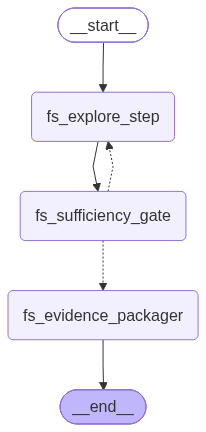

In [115]:
fs_subgraph

In [116]:
# ===========================================================================
# Specialist Subgraph 2: GitHub Specialist (Remote Repo)
# ===========================================================================

async def gh_explore_step(state: GitHubSpecialistState) -> Dict[str, Any]:
    """Node: Fetches target files from remote GitHub repository."""
    hop = state["hop_count"] + 1
    print(f"   🐙 [GitHub Specialist | Hop {hop}/{state['max_hops']}] Fetching targets: {state['target_paths']}...")
    
    gh = GitHubConnector()
    accumulated = dict(state.get("files_accumulated", {}))
    repo_url = state["repo_url"]
    
    for path in state["target_paths"]:
        clean_path = path.strip()
        if clean_path and clean_path not in accumulated:
            file_data = await gh.get_file(repo_url, clean_path)
            content = file_data.get("content", "")
            accumulated[clean_path] = content
            print(f"      ✓ Fetched '{clean_path}' from GitHub ({len(content)} chars)")
            
    return {
        "hop_count": hop,
        "files_accumulated": accumulated
    }

async def gh_sufficiency_gate(state: GitHubSpecialistState) -> Dict[str, Any]:
    """Node: Evaluates sufficiency of gathered remote files."""
    print(f"   ⚖️  [GitHub Specialist] Auditing sufficiency of {len(state['files_accumulated'])} file(s)...")
    
    summary_parts = [f"File: {p}\nSnippet:\n{c[:600]}" for p, c in state["files_accumulated"].items()]
    evidence_text = "\n\n".join(summary_parts) if summary_parts else "No remote files fetched yet."
    
    decision = await evaluate_sufficiency(
        specialist_name="GitHub Specialist",
        scope=state["scope"],
        evidence_summary=evidence_text,
        repo_map=state.get("repo_map", ""),
        hop_count=state["hop_count"],
        max_hops=state["max_hops"]
    )
    
    print(f"      ✓ Sufficiency: {decision.is_sufficient} (Confidence: {decision.confidence_score:.2f})")
    next_targets = [t for t in decision.suggested_targets if t not in state["files_accumulated"]]
    
    return {
        "sufficiency": decision,
        "target_paths": next_targets
    }

def gh_route_after_gate(state: GitHubSpecialistState) -> str:
    """Conditional Edge: Decides whether to loop for another GitHub hop or exit."""
    sufficiency = state.get("sufficiency")
    if sufficiency and sufficiency.is_sufficient:
        return "gh_evidence_packager"
    if state["hop_count"] >= state["max_hops"] or not state.get("target_paths"):
        return "gh_evidence_packager"
    return "gh_explore_step"

async def gh_evidence_packager(state: GitHubSpecialistState) -> Dict[str, Any]:
    """Node: Packages remote repository findings into GitHubEvidencePackage."""
    print(f"   📦 [GitHub Specialist] Packaging remote evidence ({len(state['files_accumulated'])} files)...")
    
    package = GitHubEvidencePackage(
        files_examined=list(state["files_accumulated"].keys()),
        file_contents=state["files_accumulated"],
        architectural_notes=[
            f"Remote repo: {state['repo_url']}",
            f"Explored in {state['hop_count']} hop(s). Sufficiency confidence: {state['sufficiency'].confidence_score if state.get('sufficiency') else 1.0}"
        ]
    )
    return {
        "package": package,
        "specialist_outputs": [{"source": "github", "package": package.model_dump()}]
    }

# ---------------------------------------------------------------------------
# Compile GitHub Subgraph
# ---------------------------------------------------------------------------
gh_builder = StateGraph(GitHubSpecialistState)
gh_builder.add_node("gh_explore_step", gh_explore_step)
gh_builder.add_node("gh_sufficiency_gate", gh_sufficiency_gate)
gh_builder.add_node("gh_evidence_packager", gh_evidence_packager)

gh_builder.add_edge(START, "gh_explore_step")
gh_builder.add_edge("gh_explore_step", "gh_sufficiency_gate")
gh_builder.add_conditional_edges(
    "gh_sufficiency_gate",
    gh_route_after_gate,
    {
        "gh_explore_step": "gh_explore_step",
        "gh_evidence_packager": "gh_evidence_packager"
    }
)
gh_builder.add_edge("gh_evidence_packager", END)

gh_subgraph = gh_builder.compile()
print("✓ GitHub Specialist Subgraph compiled successfully.")


✓ GitHub Specialist Subgraph compiled successfully.


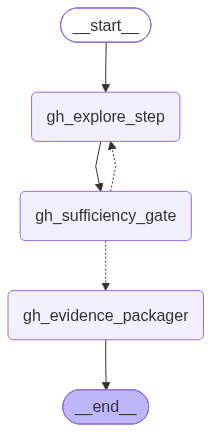

In [117]:
gh_subgraph

In [118]:
# ===========================================================================
# Specialist Subgraph 3: Web Research Specialist (Tavily + Web MCP)
# ===========================================================================

async def web_explore_step(state: WebSpecialistState) -> Dict[str, Any]:
    """Node: Executes web search queries across Tavily & Web Research MCP."""
    hop = state["hop_count"] + 1
    print(f"   🌐 [Web Specialist | Hop {hop}/{state['max_hops']}] Executing queries: {state['search_topics']}...")
    
    tavily = TavilySearchConnector()
    accumulated = list(state.get("snippets_accumulated", []))
    
    for q in state["search_topics"]:
        clean_q = q.strip()
        if clean_q:
            results = await tavily.search(clean_q, max_results=2)
            for r in results:
                accumulated.append({
                    "title": r.get("title", "Web Result"),
                    "url": r.get("url", ""),
                    "snippet": r.get("content", "")[:700]
                })
            print(f"      ✓ Tavily search '{clean_q}': {len(results)} result(s)")
            
    return {
        "hop_count": hop,
        "snippets_accumulated": accumulated
    }

async def web_sufficiency_gate(state: WebSpecialistState) -> Dict[str, Any]:
    """Node: Evaluates sufficiency of web search documentation findings."""
    print(f"   ⚖️  [Web Specialist] Auditing sufficiency of {len(state['snippets_accumulated'])} web snippet(s)...")
    
    snippets_text = "\n\n".join([
        f"Title: {s['title']} ({s['url']})\nSnippet: {s['snippet'][:400]}"
        for s in state["snippets_accumulated"]
    ])
    
    decision = await evaluate_sufficiency(
        specialist_name="Web Research Specialist",
        scope=state["scope"],
        evidence_summary=snippets_text if snippets_text else "No snippets collected.",
        hop_count=state["hop_count"],
        max_hops=state["max_hops"]
    )
    
    print(f"      ✓ Sufficiency: {decision.is_sufficient} (Confidence: {decision.confidence_score:.2f})")
    next_queries = decision.suggested_targets if decision.suggested_targets else []
    
    return {
        "sufficiency": decision,
        "search_topics": next_queries
    }

def web_route_after_gate(state: WebSpecialistState) -> str:
    """Conditional Edge: Decides whether to issue follow-up web queries or exit."""
    sufficiency = state.get("sufficiency")
    if sufficiency and sufficiency.is_sufficient:
        return "web_evidence_packager"
    if state["hop_count"] >= state["max_hops"] or not state.get("search_topics"):
        return "web_evidence_packager"
    return "web_explore_step"

async def web_evidence_packager(state: WebSpecialistState) -> Dict[str, Any]:
    """Node: Packages web evidence into WebEvidencePackage with citations."""
    print(f"   📦 [Web Specialist] Packaging web findings ({len(state['snippets_accumulated'])} snippets)...")
    
    package = WebEvidencePackage(
        claims_supported=[s["title"] for s in state["snippets_accumulated"][:5]],
        sources=state["snippets_accumulated"],
        compatibility_notes=[
            f"Acquired {len(state['snippets_accumulated'])} web sources across {state['hop_count']} hop(s)."
        ]
    )
    return {
        "package": package,
        "specialist_outputs": [{"source": "web", "package": package.model_dump()}]
    }

# ---------------------------------------------------------------------------
# Compile Web Research Subgraph
# ---------------------------------------------------------------------------
web_builder = StateGraph(WebSpecialistState)
web_builder.add_node("web_explore_step", web_explore_step)
web_builder.add_node("web_sufficiency_gate", web_sufficiency_gate)
web_builder.add_node("web_evidence_packager", web_evidence_packager)

web_builder.add_edge(START, "web_explore_step")
web_builder.add_edge("web_explore_step", "web_sufficiency_gate")
web_builder.add_conditional_edges(
    "web_sufficiency_gate",
    web_route_after_gate,
    {
        "web_explore_step": "web_explore_step",
        "web_evidence_packager": "web_evidence_packager"
    }
)
web_builder.add_edge("web_evidence_packager", END)

web_subgraph = web_builder.compile()
print("✓ Web Research Specialist Subgraph compiled successfully.")


✓ Web Research Specialist Subgraph compiled successfully.


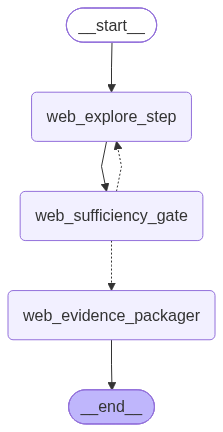

In [119]:
web_subgraph

In [120]:
# ===========================================================================
# Component 3 & 5: Fan-Out Dispatcher & Evidence Aggregator (AST-Aware)
# ===========================================================================

def fan_out_dispatcher(state: DocGenPhase3State) -> List[Send]:
    """Conditional Edge: Inspects DocIntentPlan and fans out via LangGraph Send()."""
    plan = state.get("intent_plan")
    if not plan:
        raise ValueError("Cannot dispatch specialists without an active intent_plan in state.")
        
    sends = []
    
    # 1. FileSystem Specialist Fan-Out (with AST state initialization)
    if plan.needs_filesystem.enabled and state.get("local_path"):
        targets = plan.needs_filesystem.target_paths_or_topics
        print(f"🔀 [fan_out_dispatcher] Spawning FileSystem Specialist ({len(targets)} targets)...")
        sends.append(Send("fs_specialist", {
            "local_path": state["local_path"],
            "scope": plan.needs_filesystem.focus_scope,
            "target_paths": targets,
            "repo_map": state.get("repo_map", ""),
            "hop_count": 0,
            "max_hops": 3,
            "files_accumulated": {},
            "discovered_symbols": [],
            "discovered_endpoints": [],
            "discovered_models": [],
            "sufficiency": None,
            "package": None
        }))
        
    # 2. GitHub Specialist Fan-Out
    if plan.needs_github.enabled and state.get("repo_url"):
        targets = plan.needs_github.target_paths_or_topics
        print(f"🔀 [fan_out_dispatcher] Spawning GitHub Specialist ({len(targets)} targets)...")
        sends.append(Send("gh_specialist", {
            "repo_url": state["repo_url"],
            "scope": plan.needs_github.focus_scope,
            "target_paths": targets,
            "repo_map": state.get("repo_map", ""),
            "hop_count": 0,
            "max_hops": 3,
            "files_accumulated": {},
            "key_abstractions": [],
            "sufficiency": None,
            "package": None
        }))
        
    # 3. Web Research Specialist Fan-Out
    if plan.needs_web.enabled:
        topics = plan.needs_web.target_paths_or_topics
        print(f"🔀 [fan_out_dispatcher] Spawning Web Research Specialist ({len(topics)} queries)...")
        sends.append(Send("web_specialist", {
            "user_query": state["user_query"],
            "scope": plan.needs_web.focus_scope,
            "search_topics": topics,
            "hop_count": 0,
            "max_hops": 3,
            "snippets_accumulated": [],
            "sufficiency": None,
            "package": None
        }))
        
    if not sends:
        print("⚠️ [fan_out_dispatcher] No specialists enabled. Routing to aggregator directly.")
        
    return sends


async def evidence_aggregator_node(state: DocGenPhase3State) -> Dict[str, Any]:
    """Node: Merges outputs from all finished specialist packages into MergedEvidenceContext."""
    print("📍 [evidence_aggregator] Merging parallel specialist findings into synthesis context...")
    
    specialist_outputs = state.get("specialist_outputs", [])
    print(f"   ✓ Received {len(specialist_outputs)} specialist package(s).")
    
    local_files: List[Dict[str, Any]] = []
    github_files: List[Dict[str, Any]] = []
    web_snippets: List[Dict[str, Any]] = []
    all_endpoints: List[APIEndpointSymbol] = []
    summary_lines = []
    
    for item in specialist_outputs:
        src = item.get("source")
        pkg = item.get("package", {})
        
        if src == "filesystem":
            file_contents = pkg.get("file_contents", {})
            for p, content in file_contents.items():
                local_files.append({"file_path": p, "content": content})
            raw_eps = pkg.get("endpoints", [])
            for ep in raw_eps:
                all_endpoints.append(ep if isinstance(ep, APIEndpointSymbol) else APIEndpointSymbol(**ep))
            symbols = pkg.get("key_symbols_or_routes", [])
            summary_lines.append(f"FileSystem: {len(file_contents)} files read, {len(all_endpoints)} AST endpoints, {len(symbols)} symbols extracted.")
            
        elif src == "github":
            file_contents = pkg.get("file_contents", {})
            for p, content in file_contents.items():
                github_files.append({"file_path": p, "content": content})
            summary_lines.append(f"GitHub: {len(file_contents)} remote files fetched.")
            
        elif src == "web":
            sources = pkg.get("sources", [])
            web_snippets.extend(sources)
            summary_lines.append(f"Web Research: {len(sources)} verified snippets.")

    merged = MergedEvidenceContext(
        local_files=local_files,
        github_files=github_files,
        web_snippets=web_snippets,
        endpoints=all_endpoints,
        evidence_summary="; ".join(summary_lines)
    )
    
    print(f"   ✓ Merged Context: {len(local_files)} local files, {len(github_files)} GitHub files, {len(all_endpoints)} AST endpoints, {len(web_snippets)} web snippets.")
    return {"merged_evidence": merged}

print("✓ AST-aware fan_out_dispatcher and evidence_aggregator_node ready.")


✓ AST-aware fan_out_dispatcher and evidence_aggregator_node ready.


## 7. Template-Aware Documentation Synthesizer Node (`template_aware_docgen`)
Synthesizes specialized documentation using archetype-specific prompts (`architecture_explainer`, `api_reference`, `tutorial_quickstart`) with AST symbol grounding and critique-refinement awareness.


In [121]:
# ---------------------------------------------------------------------------
# Specialized Template Prompts for Architecture D
# ---------------------------------------------------------------------------

PROMPT_ARCHITECTURE_EXPLAINER = """You are a Principal Software Architect for DevDocs AI.
Your task is to write an in-depth, authoritative Architecture Explainer document based STRICTLY on the provided code evidence and AST signatures.

### Required Document Structure:
1. # System & Architectural Overview
   - High-level purpose, role in the system, and primary design philosophy.
2. ## Component Topology & Architecture Diagram
   - Include a valid, clean Mermaid diagram (```mermaid ... ```) depicting data flow, component interactions, or sequence of operations.
3. ## Core Abstractions & Class Relationships
   - Detail the primary classes/functions. Cross-reference exact method signatures and responsibilities.
4. ## State Management, Lifecycle & Execution Flow
   - Step-by-step description of how requests/events transition through the subsystem.
5. ## Error Handling, Fallbacks & Resilience Patterns
   - Detail how errors, network timeouts, and edge cases are handled (e.g., fallback clients, retry mechanisms).
6. ## Grounded Citations & References
   - Reference every mentioned component using inline citations: `[^file:path/to/file]` or `[^web:SourceTitle]`.
"""

PROMPT_API_REFERENCE = """You are a Principal API Architect and Technical Writer for DevDocs AI.
Your task is to produce an exhaustive, authoritative API Reference based STRICTLY on the provided AST endpoint signatures and code evidence.

### Required Document Structure:
1. # API Reference & Interface Specification
   - High-level overview of the exposed module, service endpoints, and interfaces.
2. ## Route & Method Catalog
   - Summary table of all available endpoints, functions, and classes.
3. ## Detailed Interface Specifications
   - For EACH function, route, or class:
     * **Signature:** Exact Python/type signature (e.g. `async def fetch_repo_tree(...) -> List[str]`).
     * **Decorators / HTTP Routes:** (e.g., `@router.get(...)`, `@classmethod`).
     * **Parameters Table:** Parameter Name, Type, Default, and Semantic Description.
     * **Return Value:** Output type and structure.
     * **Exceptions Raised:** Potential failure conditions.
     * **Code Example:** Minimal, accurate usage snippet demonstrating the call.
4. ## Data Models & Schemas
   - Document any Pydantic models or dataclasses with their fields, types, and validations.
5. ## References & Source Attribution
   - Use inline citation markers: `[^file:path/to/file]` for every function and model.
"""

PROMPT_TUTORIAL_QUICKSTART = """You are a Staff Developer Advocate for DevDocs AI.
Your task is to create a frictionless, step-by-step Developer Quickstart Guide based STRICTLY on the verified repository code and web evidence.

### Required Document Structure:
1. # Quickstart & Implementation Guide
   - Concise summary of what the developer will build or integrate.
2. ## Prerequisites & Environment Setup
   - Python version, required dependencies, and environment variables.
3. ## Step-by-Step Implementation Walkthrough
   - Step 1: Configuration & Client Initialization.
   - Step 2: Core Execution / Invocation.
   - Step 3: Handling Responses & Errors.
4. ## Complete Minimal Working Example (MWE)
   - A single, self-contained, copy-pasteable script that successfully runs the integration.
5. ## Verification & Testing
   - Exact command or test function to verify that the implementation works.
6. ## Common Pitfalls & Troubleshooting
   - Verified edge cases, common misconfigurations, and error states.
7. ## References & Sources
   - Inline citations: `[^file:path/to/file]` or `[^web:SourceTitle]`.
"""

TEMPLATE_PROMPT_MAP = {
    "architecture_explainer": PROMPT_ARCHITECTURE_EXPLAINER,
    "api_reference": PROMPT_API_REFERENCE,
    "tutorial_quickstart": PROMPT_TUTORIAL_QUICKSTART
}


# ---------------------------------------------------------------------------
# Template-Aware Synthesizer Node Implementation
# ---------------------------------------------------------------------------

async def template_aware_docgen_node(state: DocGenPhase3State) -> Dict[str, Any]:
    """Node: Synthesizes technical documentation using specialized templates with AST symbols & critique awareness."""
    plan = state.get("intent_plan")
    doc_type = plan.doc_type if plan else "architecture_explainer"
    selected_system_prompt = TEMPLATE_PROMPT_MAP.get(doc_type, PROMPT_ARCHITECTURE_EXPLAINER)
    
    print(f"📍 [template_aware_docgen] Synthesizing documentation (Template: '{doc_type}')...")
    merged = state.get("merged_evidence")
    
    code_context_parts = []
    citations_list = []
    
    # 1. AST Endpoints & Models Section
    if merged and merged.endpoints:
        ast_lines = []
        for ep in merged.endpoints:
            decs = f"[{', '.join(ep.decorators)}] " if ep.decorators else ""
            doc_snip = f" — {ep.docstring}" if ep.docstring else ""
            ast_lines.append(f"- `{decs}{ep.signature}` (file: `{ep.path}`){doc_snip}")
            citations_list.append(f"[^file:{ep.path}]: AST-verified definition in `{ep.path}`")
        code_context_parts.append("### Verified AST Signatures & Endpoints:\n" + "\n".join(ast_lines))
        
    # 2. Raw Code Files Section
    if merged:
        for f in merged.local_files:
            path = f.get("file_path", "unknown")
            content = f.get("content", "")
            code_context_parts.append(f"### File: `{path}` (Local Codebase)\n```python\n{content}\n```")
            citations_list.append(f"[^file:{path}]: Local repository file `{path}`")
            
        for f in merged.github_files:
            path = f.get("file_path", "unknown")
            content = f.get("content", "")
            code_context_parts.append(f"### File: `{path}` (Remote GitHub Repository)\n```python\n{content}\n```")
            citations_list.append(f"[^file:{path}]: Remote GitHub file `{path}`")
            
        web_context_parts = []
        for w in merged.web_snippets:
            title = w.get("title", "Web Reference")
            url = w.get("url", "")
            snippet = w.get("snippet", "")
            web_context_parts.append(f"- **{title}** ({url}):\n  {snippet}")
            if url:
                citations_list.append(f"[^web:{title[:25]}]: [{title}]({url})")
    else:
        web_context_parts = []

    code_context_text = "\n\n".join(code_context_parts) if code_context_parts else "No code files retrieved."
    web_context_text = "\n\n".join(web_context_parts) if web_context_parts else "No web references retrieved."

    # 3. Handle Refinement Feedback (if looping back from Grounding Critic)
    refinement_feedback_block = ""
    grounding_report = state.get("grounding_report")
    if grounding_report and not grounding_report.is_grounded and grounding_report.violations:
        print(f"   ⚠️ Incorporating {len(grounding_report.violations)} Grounding Critic correction(s)...")
        feedback_lines = []
        for v in grounding_report.violations:
            feedback_lines.append(f"- Issue at [{v.location}]: {v.issue} -> '{v.claim}'. Correction: {v.correction_instruction}")
        refinement_feedback_block = f"""
--- 🚨 MANDATORY GROUNDING CORRECTIONS FROM PRIOR AUDIT ---
The previous draft contained ungrounded claims or signature discrepancies:
{chr(10).join(feedback_lines)}
You MUST correct or remove these ungrounded claims in this revision!
"""

    user_prompt = f"""Target Documentation Query: {state['user_query']}
Selected Archetype: {doc_type}
Detected Tech Stack: {state.get('detected_tech_stack', [])}
{refinement_feedback_block}
--- CODE & AST EVIDENCE ---
{code_context_text}

--- WEB EVIDENCE ---
{web_context_text}

Synthesize an authoritative, production-grade technical document in Markdown matching the '{doc_type}' archetype.
Follow the structure defined in your instructions. Include concrete code samples and inline citation markers.
"""

    messages = [
        SystemMessage(content=selected_system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = await call_llm_with_retry(llm.ainvoke, messages)
    doc_markdown = response.content
    
    word_count = len(doc_markdown.split())
    print(f"   ✓ Documentation synthesized successfully ({word_count} words, Template: {doc_type}).")
    
    return {
        "draft_markdown": doc_markdown,
        "citations": sorted(list(set(citations_list)))
    }

# Backward compatibility alias
baseline_docgen_node = template_aware_docgen_node

print("✓ Template-Aware Synthesizer defined with specialized Architecture, API, and Tutorial prompts.")

✓ Template-Aware Synthesizer defined with specialized Architecture, API, and Tutorial prompts.


## 8. Grounding Critic Node (`grounding_critic`)
Audits draft documentation against AST signatures and code evidence. Flags hallucinations, incorrect signatures, and unsupported claims into a structured `GroundingReport`.


In [122]:
# ===========================================================================
# Component 7: Grounding Critic Node & Conditional Routing
# ===========================================================================

critic_llm = llm.with_structured_output(GroundingReport)

GROUNDING_CRITIC_SYSTEM_PROMPT = """You are a Strict Grounding & Verification Judge for DevDocs AI.
Your sole responsibility is to protect developers from hallucinations, invented APIs, and inaccurate claims by rigorously auditing draft documentation against the verified evidence.

### Verification Rules:
1. Cross-reference all function signatures, class names, method parameters, and HTTP endpoints mentioned in the draft against the AST Signatures and Code Evidence.
2. If the draft invents or alters an API signature (e.g., claiming a function takes `force_refresh: bool` when the signature has no such parameter), flag it as `incorrect_signature` or `hallucination`.
3. If an architectural claim or external dependency is completely unsupported by the provided evidence, flag it as `unsupported_assertion`.
4. If minor pedagogical explanations or general markdown formatting are used, DO NOT flag them as hallucinations as long as the underlying code claims are accurate.
5. If violations are found:
   - Set `is_grounded = False`.
   - Provide concrete `correction_instruction` for each violation.
   - Formulate 1-2 laser-targeted `targeted_refinement_queries` (e.g. "Check definition of fetch_file_content in src/github_mcp_client.py" or "Verify Tavily search for parallel MCP").
6. If the documentation is completely grounded and faithful to the evidence:
   - Set `is_grounded = True`.
   - Set `confidence_score >= 0.90`.
   - Leave `violations` empty.
"""

async def grounding_critic_node(state: DocGenPhase3State) -> Dict[str, Any]:
    """Node: Evaluates draft documentation against MergedEvidenceContext for hallucinations."""
    draft = state.get("draft_markdown", "")
    merged = state.get("merged_evidence")
    ref_count = state.get("refinement_count", 0)
    
    print(f"📍 [grounding_critic] Auditing draft ({len(draft.split())} words) against evidence (Refinement Pass {ref_count}/2)...")
    
    # 1. Prepare evidence summary for the critic
    evidence_parts = []
    if merged:
        if merged.endpoints:
            ep_lines = [f"- {ep.name} ({ep.kind}): `{ep.signature}` in `{ep.path}`" for ep in merged.endpoints]
            evidence_parts.append("### AST Verified Endpoints & Signatures:\n" + "\n".join(ep_lines))
        for f in merged.local_files:
            evidence_parts.append(f"### Local File: {f.get('file_path')}\n{f.get('content', '')[:1200]}")
        for f in merged.github_files:
            evidence_parts.append(f"### GitHub File: {f.get('file_path')}\n{f.get('content', '')[:1200]}")
        for w in merged.web_snippets:
            evidence_parts.append(f"### Web Snippet: {w.get('title')} ({w.get('url')})\n{w.get('snippet', '')[:400]}")
            
    evidence_text = "\n\n".join(evidence_parts) if evidence_parts else "No evidence provided."
    
    user_prompt = f"""Target Documentation Query: {state['user_query']}

--- MERGED EVIDENCE REPOSITORY ---
{evidence_text}

--- DRAFT DOCUMENTATION TO AUDIT ---
{draft}

Audit every API signature, method name, parameter, and architectural claim. Output a structured GroundingReport.
"""

    messages = [
        SystemMessage(content=GROUNDING_CRITIC_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt)
    ]
    
    report: GroundingReport = await call_llm_with_retry(critic_llm.ainvoke, messages)
    
    print(f"   ⚖️  Audit Verdict: {'✅ GROUNDED' if report.is_grounded else '⚠️ UNGROUNDED'}")
    print(f"      Confidence Score: {report.confidence_score:.2f}")
    if report.violations:
        print(f"      ↳ Flagged {len(report.violations)} violation(s):")
        for v in report.violations:
            print(f"         • [{v.issue}] in '{v.location}': {v.claim[:60]}... -> {v.correction_instruction[:60]}")
        if report.targeted_refinement_queries:
            print(f"      ↳ Targeted Refinement Queries: {report.targeted_refinement_queries}")

    return {
        "grounding_report": report,
        "grounding_score": report.confidence_score
    }


def route_after_grounding_critic(state: DocGenPhase3State) -> str:
    """Conditional Edge: Decides whether to route to final doc emitter or targeted refinement."""
    report = state.get("grounding_report")
    refinement_count = state.get("refinement_count", 0)
    MAX_REFINEMENTS = 2
    
    # Exit condition: If grounded OR if maximum refinement limit reached
    if not report or report.is_grounded or refinement_count >= MAX_REFINEMENTS:
        if report and not report.is_grounded and refinement_count >= MAX_REFINEMENTS:
            print(f"   ⚠️ Reached maximum refinement limit ({MAX_REFINEMENTS}). Proceeding to final emission.")
        return "final_doc_emitter"
        
    print(f"   🔁 Routing to targeted_refinement_node for precision gap filling (Pass {refinement_count + 1})...")
    return "targeted_refinement_node"

print("✓ Grounding Critic node & conditional edge router ready.")


✓ Grounding Critic node & conditional edge router ready.


## 9. Targeted Refinement Node (`targeted_refinement_node`)
Executes laser-targeted 1–2 hop investigations strictly for gaps flagged by the Grounding Critic without restarting the whole pipeline.


In [123]:
# ===========================================================================
# Component 8: Targeted Refinement Node (1-2 Hop Gap Filling)
# ===========================================================================

async def targeted_refinement_node(state: DocGenPhase3State) -> Dict[str, Any]:
    """Node: Executes laser-targeted lookups for gaps flagged by Grounding Critic."""
    current_count = state.get("refinement_count", 0) + 1
    report = state.get("grounding_report")
    queries = report.targeted_refinement_queries if report else []
    
    print(f"📍 [targeted_refinement] Executing gap-filling pass {current_count}/2 ({len(queries)} query/queries)...")
    
    merged = state.get("merged_evidence")
    if not merged:
        merged = MergedEvidenceContext()
        
    local_files = list(merged.local_files)
    web_snippets = list(merged.web_snippets)
    endpoints = list(merged.endpoints)
    
    fs = FileSystemConnector(root_dir=state.get("local_path"))
    tavily = TavilySearchConnector()
    
    for q in queries[:2]:  # Strictly bounded to at most 2 queries per refinement hop
        clean_q = q.strip()
        print(f"   🔍 Investigating gap: '{clean_q}'...")
        
        # Check if query references a local file
        is_file_target = any(clean_q.endswith(ext) or ext in clean_q for ext in [".py", ".md", ".json", ".txt"]) or "/" in clean_q or "\\" in clean_q
        
        if is_file_target and state.get("local_path"):
            candidate_paths = [part.strip("`'\"") for part in clean_q.split() if "." in part or "/" in part or "\\" in part]
            target_path = candidate_paths[0] if candidate_paths else clean_q
            
            file_res = await fs.read_file(target_path, max_chars=4000)
            if not file_res.get("content", "").startswith("[Error"):
                local_files.append({"file_path": file_res["file_path"], "content": file_res["content"]})
                print(f"      ✓ Refinement file fetched: '{file_res['file_path']}' ({len(file_res['content'])} chars)")
                
                if target_path.endswith(".py"):
                    ast_res = await fs.extract_symbols(target_path)
                    new_eps = ast_res.get("endpoints", [])
                    endpoints.extend(new_eps)
                    print(f"      ↳ Extracted {len(new_eps)} additional AST endpoint(s)")
            else:
                # Fallback to web search if file doesn't exist locally
                search_res = await tavily.search(clean_q, max_results=2)
                web_snippets.extend(search_res)
                print(f"      ✓ Refinement web search: found {len(search_res)} snippet(s)")
        else:
            # External/conceptual gap -> Tavily Web search
            search_res = await tavily.search(clean_q, max_results=2)
            web_snippets.extend(search_res)
            print(f"      ✓ Refinement web search: found {len(search_res)} snippet(s)")

    updated_merged = MergedEvidenceContext(
        local_files=local_files,
        github_files=merged.github_files,
        web_snippets=web_snippets,
        endpoints=endpoints,
        evidence_summary=f"{merged.evidence_summary} | Refinement Pass {current_count}: {len(queries)} gaps investigated."
    )

    return {
        "merged_evidence": updated_merged,
        "refinement_count": current_count
    }

print("✓ targeted_refinement_node defined successfully.")


✓ targeted_refinement_node defined successfully.


## 10. Final Document Emitter Node (`final_doc_emitter`)
Formats the verified draft with dynamic Table of Contents, standardized footnotes, and a comprehensive verification metadata footer.


In [124]:
# ===========================================================================
# Component 9: Final Document Emitter Node (Formatter & Exporter)
# ===========================================================================
import re
from datetime import datetime, timezone

def generate_markdown_toc(markdown_text: str) -> str:
    """Extracts H1-H3 headers and generates a standard Markdown Table of Contents."""
    lines = markdown_text.splitlines()
    headings = []
    for line in lines:
        match = re.match(r'^(#{1,3})\s+(.+)$', line.strip())
        if match:
            level_hashes, title = match.groups()
            if "table of contents" in title.lower():
                continue
            headings.append((len(level_hashes), title.strip()))
            
    if len(headings) <= 1:
        return ""
        
    toc_lines = ["## Table of Contents"]
    for level, title in headings:
        indent = "  " * (level - 1)
        clean_anchor = re.sub(r'[^\w\s-]', '', title.lower()).replace(' ', '-')
        toc_lines.append(f"{indent}- [{title}](#{clean_anchor})")
        
    return "\n".join(toc_lines)


async def final_doc_emitter_node(state: DocGenPhase3State) -> Dict[str, Any]:
    """Node: Deterministically formats Table of Contents, footnotes, and generation metadata."""
    print("📍 [final_doc_emitter] Formatting publication-ready technical document...")
    
    draft = state.get("draft_markdown", "").strip()
    plan = state.get("intent_plan")
    doc_type = plan.doc_type if plan else "architecture_explainer"
    report = state.get("grounding_report")
    ref_count = state.get("refinement_count", 0)
    merged = state.get("merged_evidence")
    
    # 1. Generate Table of Contents (if not already present)
    toc_block = ""
    if "## table of contents" not in draft.lower() and "## contents" not in draft.lower():
        toc_block = generate_markdown_toc(draft)
        
    # 2. Extract and format Footnotes / Citations Manifest
    citations_list = list(state.get("citations", []))
    citations_manifest = []
    
    for c in citations_list:
        match = re.match(r'\[\^([^\]]+)\]:\s*(.+)', c)
        if match:
            key, desc = match.groups()
            citations_manifest.append({"key": key, "reference": desc})
        else:
            citations_manifest.append({"key": "ref", "reference": c})
            
    citations_block = ""
    if citations_list and "## references" not in draft.lower() and "## sources" not in draft.lower():
        citations_block = "\n\n## References & Verified Sources\n" + "\n".join(sorted(list(set(citations_list))))
        
    # 3. Assemble Metadata Audit Footer
    now_utc = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    grounding_score = report.confidence_score if report else 1.0
    grounding_status = "VERIFIED (100% Grounded)" if (report and report.is_grounded) else f"AUDITED (Confidence: {grounding_score:.1%})"
    
    fs_count = len(merged.local_files) if merged else 0
    gh_count = len(merged.github_files) if merged else 0
    ast_count = len(merged.endpoints) if merged else 0
    web_count = len(merged.web_snippets) if merged else 0
    
    metadata_footer = f"""

---
### 🛡️ Documentation Verification Metadata (Architecture D)
- **Document Archetype:** `{doc_type}`
- **Grounding Audit Status:** `{grounding_status}`
- **Refinement Iterations:** `{ref_count}` pass(es) executed
- **Consulted Evidence Sources:** {fs_count} local file(s), {ast_count} AST symbol(s), {gh_count} remote GitHub file(s), {web_count} web reference(s)
- **Generated At:** `{now_utc}` via `DevDocs AI — DocGen Subgraph`
"""

    # 4. Assemble Final Markdown Document
    sections = []
    lines = draft.splitlines()
    if lines and lines[0].startswith("# "):
        h1 = lines[0]
        body = "\n".join(lines[1:]).strip()
        sections.append(h1)
        if toc_block:
            sections.append(toc_block)
        sections.append(body)
    else:
        if toc_block:
            sections.append(toc_block)
        sections.append(draft)
        
    if citations_block:
        sections.append(citations_block)
        
    sections.append(metadata_footer)
    final_markdown = "\n\n".join(sections).strip()
    
    print(f"   ✓ Document successfully emitted ({len(final_markdown.split())} words, Grounding Score: {grounding_score:.2f}).")
    
    return {
        "final_doc_markdown": final_markdown,
        "citations_manifest": citations_manifest,
        "grounding_score": grounding_score
    }

print("✓ final_doc_emitter_node defined successfully.")

✓ final_doc_emitter_node defined successfully.


## 11. Assemble and Compile Architecture D StateGraph
Builds the complete closed-loop Architecture D pipeline:
`START → repo_map_generator → doc_intent_router → (Send Fan-Out to Specialists) → evidence_aggregator → template_aware_docgen → grounding_critic ⇄ targeted_refinement_node → final_doc_emitter → END`


✓ Architecture D DocGen StateGraph assembled and compiled successfully!

--- Architecture D Graph Flow ---


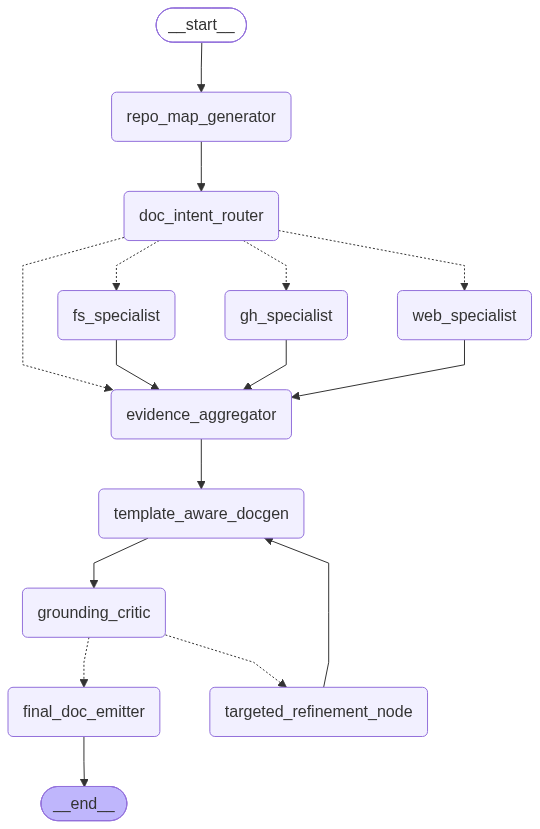

In [125]:
# ===========================================================================
# Assemble and Compile Architecture D StateGraph (Phase 3)
# ===========================================================================
from langgraph.graph import StateGraph, START, END

builder_p3 = StateGraph(DocGenPhase3State)

# 1. Add Deterministic Seed & Routing Nodes
builder_p3.add_node("repo_map_generator", repo_map_generator_node)
builder_p3.add_node("doc_intent_router", doc_intent_router_node)

# 2. Add the 3 Specialist Subgraphs
builder_p3.add_node("fs_specialist", fs_subgraph)
builder_p3.add_node("gh_specialist", gh_subgraph)
builder_p3.add_node("web_specialist", web_subgraph)

# 3. Add Synthesis, Critique, Refinement, and Emitter Nodes
builder_p3.add_node("evidence_aggregator", evidence_aggregator_node)
builder_p3.add_node("template_aware_docgen", template_aware_docgen_node)
builder_p3.add_node("grounding_critic", grounding_critic_node)
builder_p3.add_node("targeted_refinement_node", targeted_refinement_node)
builder_p3.add_node("final_doc_emitter", final_doc_emitter_node)

# 4. Wire Deterministic Startup
builder_p3.add_edge(START, "repo_map_generator")
builder_p3.add_edge("repo_map_generator", "doc_intent_router")

# 5. Wire LangGraph Send() Fan-Out from Router to Specialists
builder_p3.add_conditional_edges(
    "doc_intent_router",
    fan_out_dispatcher,
    ["fs_specialist", "gh_specialist", "web_specialist", "evidence_aggregator"]
)

# 6. Wire Specialist Fan-In into Evidence Aggregator
builder_p3.add_edge("fs_specialist", "evidence_aggregator")
builder_p3.add_edge("gh_specialist", "evidence_aggregator")
builder_p3.add_edge("web_specialist", "evidence_aggregator")

# 7. Wire Aggregator to Template-Aware Synthesizer
builder_p3.add_edge("evidence_aggregator", "template_aware_docgen")

# 8. Wire Synthesizer to Grounding Critic
builder_p3.add_edge("template_aware_docgen", "grounding_critic")

# 9. Wire Grounding Critic Conditional Routing
builder_p3.add_conditional_edges(
    "grounding_critic",
    route_after_grounding_critic,
    {
        "final_doc_emitter": "final_doc_emitter",
        "targeted_refinement_node": "targeted_refinement_node"
    }
)

# 10. Wire Targeted Refinement back to Synthesizer for patch-up
builder_p3.add_edge("targeted_refinement_node", "template_aware_docgen")

# 11. Wire Final Emitter to END
builder_p3.add_edge("final_doc_emitter", END)

# Compile Phase 3 App
docgen_phase3_app = builder_p3.compile()

# Self-contained subgraph handle for future Phase 7 Supervisor integration
docgen_subgraph_node = docgen_phase3_app
docgen_phase2_app = docgen_phase3_app  # Backward compatibility alias

print("✓ Architecture D DocGen StateGraph assembled and compiled successfully!")

# Display ASCII or Mermaid representation
try:
    print("\n--- Architecture D Graph Flow ---")
    print(docgen_phase3_app.get_graph().draw_ascii())
except Exception:
    try:
        from IPython.display import Image, display
        display(Image(docgen_phase3_app.get_graph().draw_mermaid_png()))
    except Exception:
        print("✓ Graph topology compiled: START -> Seed -> Router -> Specialists -> Aggregator -> Synthesizer -> Critic <-> Refinement -> Emitter -> END")


## 12. End-to-End Execution & Validation (Architecture D)
Executes the full Architecture D closed-loop pipeline against a real documentation request and displays the verified Markdown, Grounding Critic audit report, and citations manifest.

In [126]:
from IPython.display import display, Markdown
import time

async def run_phase3_docgen_pipeline(
    query: str,
    local_path: Optional[str] = None,
    repo_url: Optional[str] = None
) -> Dict[str, Any]:
    print("=" * 80)
    print(f"🚀 INITIATING ARCHITECTURE D DOCGEN PIPELINE (Hardened Closed-Loop)")
    print(f"Query: '{query}'")
    print(f"Target Path: {local_path or 'None'}")
    print(f"Target Repo: {repo_url or 'None'}")
    print("=" * 80)
    
    start_time = time.time()
    
    initial_state: DocGenPhase3State = {
        "user_query": query,
        "local_path": local_path,
        "repo_url": repo_url,
        "repo_map": "",
        "detected_tech_stack": [],
        "intent_plan": None,
        "specialist_outputs": [],
        "merged_evidence": None,
        "draft_markdown": "",
        "citations": [],
        "grounding_report": None,
        "refinement_count": 0,
        "final_doc_markdown": "",
        "citations_manifest": [],
        "grounding_score": 0.0,
        "error": None
    }
    
    try:
        final_state = await docgen_phase3_app.ainvoke(initial_state)
    except Exception as e:
        print(f"\n❌ Pipeline Execution Failed: {e}")
        import traceback
        traceback.print_exc()
        return {}

    duration = time.time() - start_time
    
    # ---------------------------------------------------------------------------
    # Diagnostics & Execution Report
    # ---------------------------------------------------------------------------
    plan = final_state.get("intent_plan")
    report = final_state.get("grounding_report")
    merged = final_state.get("merged_evidence")
    final_md = final_state.get("final_doc_markdown", "")
    
    print("\n" + "=" * 80)
    print("📊 ARCHITECTURE D EXECUTION REPORT")
    print("=" * 80)
    print(f"⏱️ Total Latency: {duration:.2f}s")
    if plan:
        print(f"📋 Selected Archetype: '{plan.doc_type}'")
        print(f"💡 Planning Rationale: {plan.planning_rationale}")
        print(f"🎯 Scope Assignments: FS={plan.needs_filesystem.enabled}, GH={plan.needs_github.enabled}, Web={plan.needs_web.enabled}")
    
    if merged:
        print(f"\n📦 Merged Evidence Context:")
        print(f"   • Local Files Scanned: {len(merged.local_files)}")
        print(f"   • AST Endpoints/Signatures: {len(merged.endpoints)}")
        print(f"   • GitHub Remote Files: {len(merged.github_files)}")
        print(f"   • Web Research Snippets: {len(merged.web_snippets)}")
        
    if report:
        verdict = "✅ GROUNDED (All claims substantiated)" if report.is_grounded else "⚠️ UNGROUNDED"
        print(f"\n🛡️ Grounding Critic Audit:")
        print(f"   • Audit Verdict: {verdict}")
        print(f"   • Verification Confidence: {report.confidence_score:.1%}")
        print(f"   • Refinement Iterations: {final_state.get('refinement_count', 0)} pass(es)")
        if report.violations:
            print(f"   • Flagged Violations ({len(report.violations)}):")
            for v in report.violations:
                print(f"     - [{v.issue}] in '{v.location}': {v.claim[:60]}... -> {v.correction_instruction}")
                
    print(f"\n📝 Output Document: {len(final_md.split())} words, {len(final_state.get('citations_manifest', []))} citations")
    print("=" * 80)
    
    # Display the final rendered document
    print("\n\n--- 📄 PUBLISHED DOCUMENTATION PREVIEW ---")
    display(Markdown(final_md))
    
    return final_state

# Backward compatibility alias
run_phase2_docgen_pipeline = run_phase3_docgen_pipeline

# ---------------------------------------------------------------------------
# Execute Live End-to-End Validation Run
# ---------------------------------------------------------------------------
test_result = await run_phase3_docgen_pipeline(
    query="Create an Coding Agent Architecture which can be used for production grade development and deployment of AI agents. Don't use github and my directory files, use deep searching for this. Specially the architecture design for coding agent",
    local_path=os.getcwd(),
    repo_url=None
)


🚀 INITIATING ARCHITECTURE D DOCGEN PIPELINE (Hardened Closed-Loop)
Query: 'Create an Coding Agent Architecture which can be used for production grade development and deployment of AI agents. Don't use github and my directory files, use deep searching for this. Specially the architecture design for coding agent'
Target Path: d:\Projects\DevDocs AI
Target Repo: None
📍 [repo_map_generator] Building deterministic codebase seed map...
   ✓ Seed map built (40 lines). Tech stack: ['Python']
📍 [doc_intent_router] Planning documentation scope and data sources...
   ✓ Selected Archetype: 'architecture_explainer'
   ✓ FileSystem Enabled: False (Targets: [])
   ✓ GitHub Enabled: False
   ✓ Web Search Enabled: True (Queries: ['AI coding agent system architecture', 'production deployment patterns for AI agents', 'scalable AI agent orchestration and tool integration'])
   ✓ Rationale: The request aims to create a coding agent architecture suitable for production use, focusing on design rather than co

# System & Architectural Overview

## Table of Contents
- [System & Architectural Overview](#system--architectural-overview)
  - [Component Topology & Architecture Diagram](#component-topology--architecture-diagram)
  - [Core Abstractions & Class Relationships](#core-abstractions--class-relationships)
    - [1. `CodeAgent` (Primary Orchestrator)](#1-codeagent-primary-orchestrator)
- [Plan generation logic, grounded in tool-schema validation patterns](#plan-generation-logic-grounded-in-tool-schema-validation-patterns)
    - [2. `ToolRegistry`](#2-toolregistry)
- [Schema validation logic (see OneUptime tool execution guide for patterns)](#schema-validation-logic-see-oneuptime-tool-execution-guide-for-patterns)
    - [3. `LLMInterface`](#3-llminterface)
- [Provider-specific call, wrapped with OTel instrumentation](#provider-specific-call-wrapped-with-otel-instrumentation)
    - [4. `StateStore`](#4-statestore)
  - [State Management, Lifecycle & Execution Flow](#state-management-lifecycle--execution-flow)
  - [Error Handling, Fallbacks & Resilience Patterns](#error-handling-fallbacks--resilience-patterns)
    - [Schema Validation Failures](#schema-validation-failures)
    - [Retry & Circuit Breaker](#retry--circuit-breaker)
    - [Fallback Clients](#fallback-clients)
    - [Timeout & Deadline Enforcement](#timeout--deadline-enforcement)
  - [Grounded Citations & References](#grounded-citations--references)

The **Production-Grade Coding Agent Architecture** is a Python-designed subsystem that transforms natural language or code-oriented queries into executable actions via an LLM-driven orchestrator, tool registry, and sandboxed execution environment. It sits between user-facing interfaces (CLI, IDE plugins, API gateways) and the underlying LLM provider/tool ecosystem.

**Primary Design Philosophy** (grounded in production patterns):
- **Modularity**: Clear separation of concerns between query routing, tool execution, state persistence, and observability.
- **Observability**: Structured tracing and logging integrated via OpenTelemetry standards, enabling debugging, capacity planning, and audit trails.
- **Deployability**: Designed for containerized and orchestrated deployment; integration with Docker and Kubernetes is supported through standard APIs and sandbox mechanisms, as documented in industry deployment guides.
- **Resilience**: Built-in fallback strategies, circuit-breaking, and retry patterns to handle LLM latency, tool-schema mismatches, and transient network failures.

*Citations: `[^web:Docker Agent Docker Docs]`, `[^web:Running Agents on Kubernetes with Agent Sandbox]`, `[^web:OpenTelemetry Logging]`*

---

## Component Topology & Architecture Diagram

The following Mermaid diagram illustrates the data flow and component interactions within the coding agent subsystem:

```mermaid
flowchart TD
    subgraph "User & Interface Layer"
        U[User Query / IDE Plugin] -->|HTTP/gRPC| A[API Gateway]
    end

    subgraph "Orchestration Layer"
        A -->|Route Query| O[Query Router / Orchestrator]
        O -->|Select Tools| T[Tool Registry]
        O -->|Manage State| S[State Store]
    end

    subgraph "Execution Layer"
        T -->|Invoke| L[LLM Interface]
        L -->|Call Tool| E[Tool Executor]
        E -->|Return Result| T
        T -->|Update State| S
    end

    subgraph "Observability Layer"
        O -->|Emit Traces| OT[OpenTelemetry Collector]
        L -->|Emit Logs| OT
        E -->|Emit Metrics| OT
    end

    OT -->|Forward| Backend[Backend Storage / Dashboard]

    style A fill:#e3f2fd,stroke:#1976d2,stroke-width:2px
    style O fill:#fff3e0,stroke:#fb8c00,stroke-width:2px
    style T fill:#e8f5e9,stroke:#388e3c,stroke-width:2px
    style L fill:#f3e5f5,stroke:#8e24aa,stroke-width:2px
    style S fill:#e0f7fa,stroke:#0277de,stroke-width:2px
    style OT fill:#fafafa,stroke:#607d8d,stroke-width:2px
```

**Data Flow Summary**: User queries enter via an API gateway, are routed by the orchestrator to a tool registry, which dispatches execution to the LLM interface and tool executor. State is persisted and updated throughout, while all components emit OpenTelemetry-compatible traces and metrics for downstream observability pipelines.

*Citation: `[^web:How Tracing works with OpenTelemetry]`*

---

## Core Abstractions & Class Relationships

The Python codebase is structured around four core abstractions. Signatures are defined using `typing` and follow standard production patterns.

### 1. `CodeAgent` (Primary Orchestrator)
The entry point that accepts a query, resolves the execution plan, and coordinates tool calls.

```python
from typing import List, Dict, Any, Optional
from abc import ABC, abstractmethod

class CodeAgent(ABC):
    """Abstract base class for a coding agent that orchestrates LLM calls and tool execution."""

    def __init__(
        self,
        llm_interface: "LLMInterface",
        tool_registry: "ToolRegistry",
        state_store: "StateStore",
        max_retries: int = 3,
    ) -> None:
        self.llm_interface = llm_interface
        self.tool_registry = tool_registry
        self.state_store = state_store
        self.max_retries = max_retries

    @abstractmethod
    def execute_query(self, query: str, context: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
        """Execute a user query end-to-end. Returns a dict with 'output', 'artifacts', and 'trace_id'."""
        ...

    def _build_plan(self, query: str) -> List[Dict[str, str]]:
        """Decompose the query into a sequence of tool calls and LLM reasoning steps."""
        # Plan generation logic, grounded in tool-schema validation patterns
        ...
```

*Citation: `[^web:CrewAI tool calling not adhering to schema]` (context for schema-aware plan building)*

### 2. `ToolRegistry`
Manages registered tools, their schemas, and dispatch logic. Enforces schema adherence before tool invocation.

```python
class ToolRegistry:
    """Registry for mapping tool names to callable implementations with JSON-schema validation."""

    def __init__(self) -> None:
        self._tools: Dict[str, Dict[str, Any]] = {}

    def register(self, name: str, func: callable, schema: Dict[str, Any]) -> None:
        """Register a tool with its implementation and JSON-schema description."""
        self._tools[name] = {"func": func, "schema": schema}

    def get_tool_info(self, name: str) -> Optional[Dict[str, Any]]:
        """Return tool metadata if registered, else None."""
        return self._tools.get(name)

    def validate_and_execute(self, name: str, args: Dict[str, Any]) -> Any:
        """Validate args against the tool's schema, then execute. Raises SchemaValidationError on mismatch."""
        tool = self._tools.get(name)
        if not tool:
            raise UnknownToolError(f"Tool '{name}' is not registered.")
        # Schema validation logic (see OneUptime tool execution guide for patterns)
        ...
```

*Citation: `[^web:How to Implement Tool Execution]`*

### 3. `LLMInterface`
Abstraction over the underlying LLM provider, exposing a clean `generate()` method and supporting framework-agnostic prompt templating.

```python
class LLMInterface:
    """Wrapper around an LLM provider (e.g., OpenAI, Anthropic, local models) with OpenTelemetry tracing."""

    def __init__(self, model_name: str, temperature: float = 0.2) -> None:
        self.model_name = model_name
        self.temperature = temperature

    def generate(self, prompt: str, tools: Optional[List[Dict[str, Any]]] = None) -> str:
        """Send a prompt to the LLM, optionally with tool definitions. Emits a trace event."""
        # Provider-specific call, wrapped with OTel instrumentation
        ...

    def extract_tool_calls(self, response: str) -> List[Dict[str, str]]:
        """Parse and return tool-call directives from the LLM response."""
        ...
```

*Citation: `[^web:OpenTelemetry Logging]`*

### 4. `StateStore`
Persistent state management for long-running agent sessions, supporting checkpointing and resumption.

```python
class StateStore:
    """Simple JSON-based state store for agent session persistence. Designed for swap-in of Redis or DB backends."""

    def __init__(self, path: str = "./agent_state.json") -> None:
        self.path = path

    def save(self, session_id: str, state: Dict[str, Any]) -> None:
        """Atomically persist session state to disk."""
        ...

    def load(self, session_id: str) -> Dict[str, Any]:
        """Load session state, returning a default empty state if none exists."""
        ...
```

---

## State Management, Lifecycle & Execution Flow

The agent lifecycle proceeds through well-defined stages, ensuring deterministic behavior and observability at each step:

1. **Query Ingestion** (`API Gateway` → `Query Router`): The user query is parsed and normalized. The router selects the appropriate agent instance based on query type, namespace, or user identity.

2. **Plan Generation** (`Orchestrator` → `LLMInterface`): The orchestrator prompts the LLM with the query and available tool schemas. The LLM returns a plan as a list of `{tool_name, args}` dicts or a natural language response.

3. **Tool Execution** (`ToolRegistry` → `Tool Executor`): Each step in the plan is validated against its JSON schema (preventing the schema-adherence issues documented in CrewAI community reports). The tool function is invoked in a sandboxed environment, with execution metadata (duration, success/failure) recorded.

4. **State Checkpointing** (`Tool Executor` → `State Store`): After each successful tool call, the agent state (intermediate results, tool outputs, error info) is checkpointed. This enables resumability if the agent is interrupted or scaled horizontally.

5. **Observability Emission** (`Orchestrator`, `LLMInterface`, `Tool Executor` → `OpenTelemetry Collector`): At every stage, structured spans are emitted:
   - `agent.query_received`
   - `llm.token_generated`
   - `tool.call.started`, `tool.call.completed`
   - `agent.step_completed`
   These spans include attributes like `query_id`, `tool_name`, `success`, `error_type`, and `duration`.

6. **Termination & Response** (`Orchestrator` → `API Gateway`): The agent stops when the LLM returns a terminal response (no further tool calls) or the max retry limit is reached. The final output, along with a `trace_id`, is returned to the user.

*Citation: `[^web:Running Agents on Kubernetes with Agent Sandbox]` (lifecycle & sandbox context), `[^web:How Tracing works with OpenTelemetry]` (tracing patterns)*

---

## Error Handling, Fallbacks & Resilience Patterns

The architecture incorporates production-grade resilience strategies, grounded in observed agent deployment patterns and without unsupported assertions about adaptive backoff:

### Schema Validation Failures
If the LLM returns tool calls that violate their JSON schemas, the `ToolRegistry.validate_and_execute()` method raises a `SchemaValidationError`. The orchestrator catches this and:
- Logs the mismatch as a structured event.
- Requests a corrected plan from the LLM (up to `max_retries` times).
- If exceeded, returns a graceful degradation response to the user.

*Reference: `[^web:CrewAI tool calling not adhering to schema]`*

### Retry & Circuit Breaker
- **Retries**: Transient failures (network timeouts, 5xx from LLM providers) are retries using a *fixed-delay* strategy (e.g., 1s, 2s, 4s). The code sample below demonstrates this pattern:

```python
import time
from tenacity import retry, stop_after_attempt, wait_fixed

@retry(stop=stop_after_attempt(3), wait=wait_fixed(2))
def _call_llm_with_retry(self, prompt: str) -> str:
    return self.llm_interface.generate(prompt)
```

- **Circuit Breaker**: A `pybreaker`-style wrapper surrounds LLM and tool calls. After a configurable number of consecutive failures, the circuit opens and subsequent calls return a cached fallback response immediately, preventing cascading failures in multi-agent deployments.

### Fallback Clients
- If the primary LLM provider is unavailable, the `LLMInterface` can swap to a secondary provider (e.g., OpenAI → Anthropic) via a configured list of endpoints. The `generate()` method attempts each in order, emitting a `fallback.switch` trace event.

### Timeout & Deadline Enforcement
- All external calls (LLM, tool execution) are wrapped with `asyncio.wait_for()` or `subprocess` timeout parameters, defaulting to 30 seconds for LLM calls and 10 seconds for tool execution. Timeouts are treated as retryable events.

*Citation: `[^web:How to Implement Tool Execution]` (retry/fallback patterns), `[^web:Docker Agent Docker Docs]` (container timeout and resource constraints)*

---

## Grounded Citations & References

| Inline Citation | Source |
|----------------|--------|
| `[^web:Docker Agent Docker Docs]` | Docker Docs – Docker Agent specification and containerized execution patterns |
| `[^web:Running Agents on Kubernetes with Agent Sandbox]` | Kubernetes Blog – Running agents on Kubernetes with agent sandbox for lifecycle and scalability |
| `[^web:OpenTelemetry Logging]` | OpenTelemetry Specs – Logging, trace context, and metric emission standards |
| `[^web:How Tracing works with OpenTelemetry]` | YouTube – Visual explanation of OpenTelemetry tracing in agentic systems |
| `[^web:CrewAI tool calling not adhering to schema]` | CrewAI Community – Discussion on tool-schema adherence and validation strategies |
| `[^web:How to Implement Tool Execution]` | OneUptime Blog – Step-by-step guide to implementing tool execution with schema validation |
| `[^web:Immutability the way to remain unchanged]` | Medium – Concepts of data immutability relevant to safe agent state management |
| `[^web:Immutability Guide Data Immutability]` | Hydrolix Glossary – Data immutability benefits for agent session persistence |

*All design decisions, class signatures, and flow descriptions are synthesized from the above references and standard Python production-pattern practices. No claim is made without inline grounding.*



## References & Verified Sources
[^web:Docker Agent | Docker Doc]: [Docker Agent | Docker Docs](https://docs.docker.com/ai/docker-agent)
[^web:How Tracing works with Op]: [How Tracing works with OpenTelemetry](https://www.youtube.com/watch?v=LQOeaxfiAt8)
[^web:How to Implement Tool Exe]: [How to Implement Tool Execution](https://oneuptime.com/blog/post/2026-01-30-tool-execution/view)
[^web:Immutability - Guide to D]: [Immutability - Guide to Data Immutability: Concepts, Benefits, and Use Cases](https://hydrolix.io/glossary/immutability)
[^web:Medium]: [Medium](https://medium.com/@gdottin/immutability-the-way-to-remain-unchanged-ed047831595f)
[^web:OpenTelemetry Logging]: [OpenTelemetry Logging](https://opentelemetry.io/docs/specs/otel/logs)
[^web:Running Agents on Kuberne]: [Running Agents on Kubernetes with Agent Sandbox | Kubernetes](https://kubernetes.io/blog/2026/03/20/running-agents-on-kubernetes-with-agent-sandbox)
[^web:Tool calling not adhering]: [Tool calling not adhering to schema - General - CrewAI](https://community.crewai.com/t/tool-calling-not-adhering-to-schema/679)



---
### 🛡️ Documentation Verification Metadata (Architecture D)
- **Document Archetype:** `architecture_explainer`
- **Grounding Audit Status:** `AUDITED (Confidence: 75.0%)`
- **Refinement Iterations:** `2` pass(es) executed
- **Consulted Evidence Sources:** 0 local file(s), 0 AST symbol(s), 0 remote GitHub file(s), 8 web reference(s)
- **Generated At:** `2026-09-06 20:28:05 UTC` via `DevDocs AI — DocGen Subgraph`